# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 11     |  |
| :-------------|:-------------|
| Hugo Rutten | 6541593 |
| Yael Jawahierkhan | 6444504 |
| Matteo Leonardi | 6391494 |

In [14]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Yael Jawahierkhan','Matteo Leonardi']

## Opdracht 1: Planning.

| Planning Groep: 11     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren van de sensor af | 11:30 |
| Testen meetopstelling | 12:00 |
| Algoritme iteratie 0 af | 15:00 |
| Iteraties maken | 16:30 |
| Alles testen en opruimen | 16:30-17:30 |
| groep aanwezig 1| 10:45 |
| Pauze 1| 12:45-13:45 |


## Opdracht 2: Import libs.

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [11]

<img src="KalibratieOpstelling.jpeg" width="400">

a= 0.03440668755754128
b =  0.3237959096074584


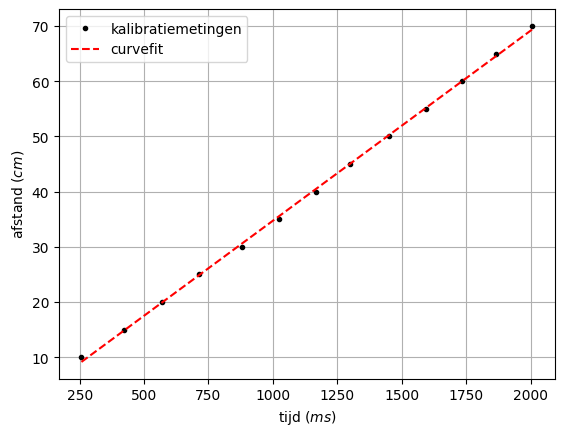

In [16]:
# verwerk hier jullie kalibratiemetingen
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


tijden = np.array([257,424,569,715,881,1023,1167,1301,1450,1595,1735,1867,2007]) #ms
afstanden = np.array([10.0,15.0,20.0, 25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0]) #cm

x_test = np.linspace(np.min(tijden),np.max(tijden))

def fit(x,a,b):
    return a*x+b

val, cov = curve_fit(fit,tijden,afstanden)

print('a=', val[0])
print( 'b = ', val[1])


plt.figure()
plt.plot(tijden,afstanden,'k.',label='kalibratiemetingen')
plt.plot(x_test,fit(x_test,*val),'r--',label='curvefit')
plt.ylabel('afstand $(cm)$')
plt.xlabel('tijd $(ms)$')
plt.grid()
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  44.47
1   0  30   0  20  45.52
2  40   0  30   0  47.95
3  30   0  20   0  47.58


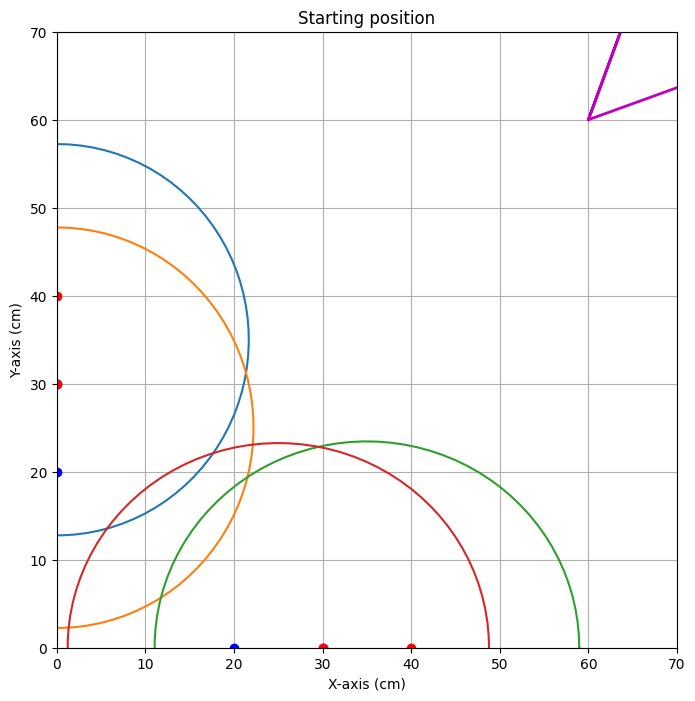


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.575


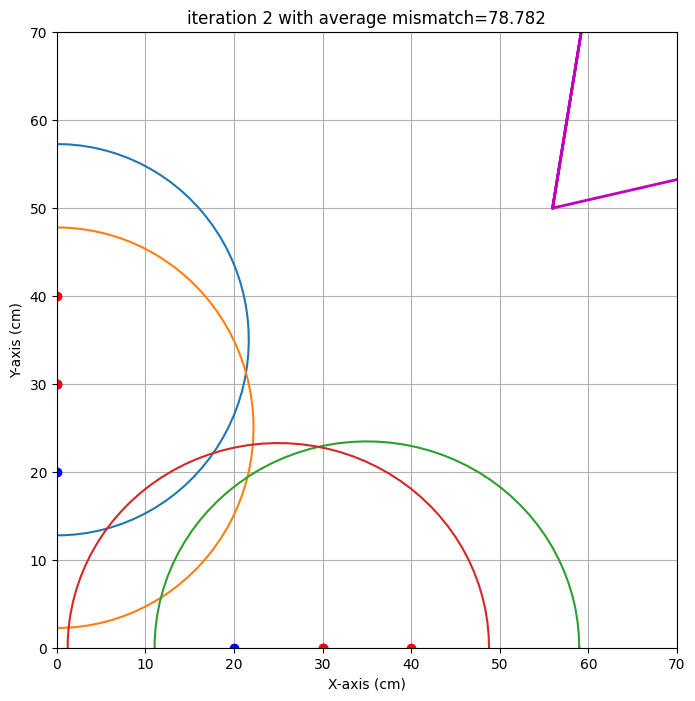

end iteration 2 with average mismatch=78.782


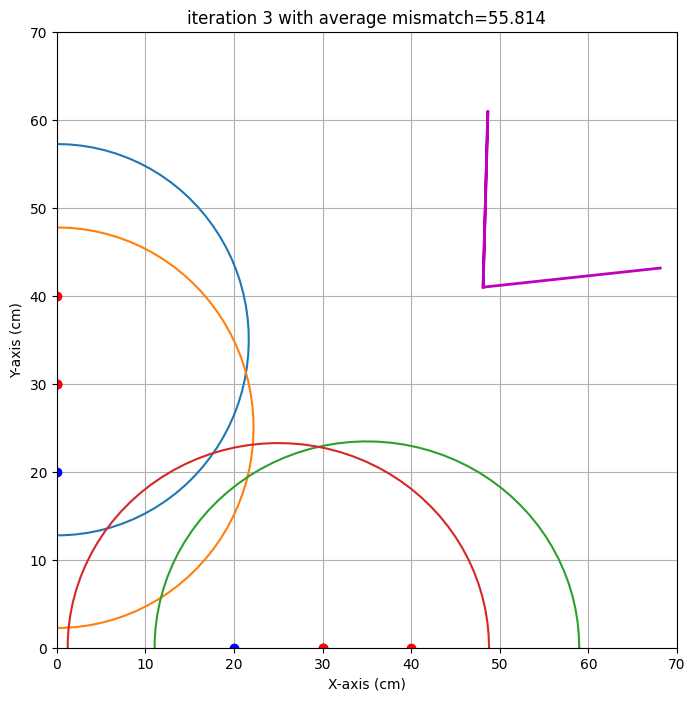

end iteration 3 with average mismatch=55.814


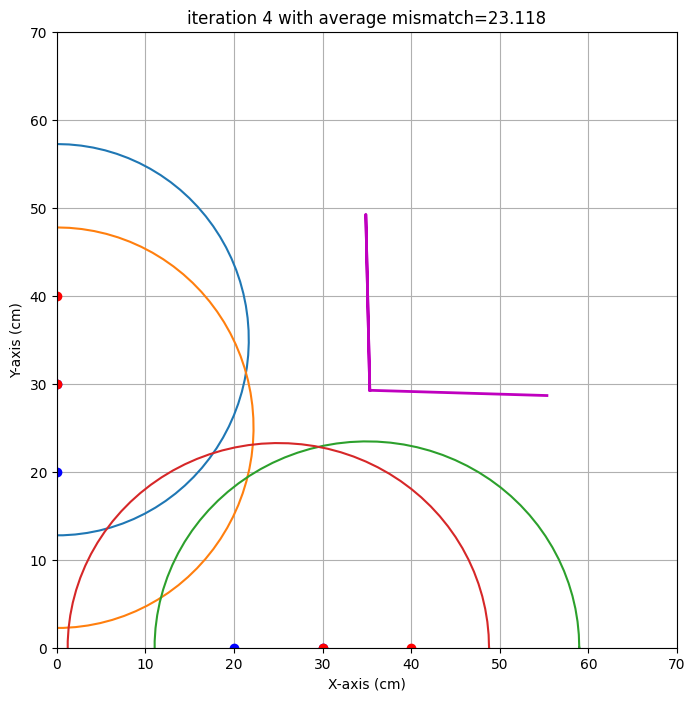

end iteration 4 with average mismatch=23.118


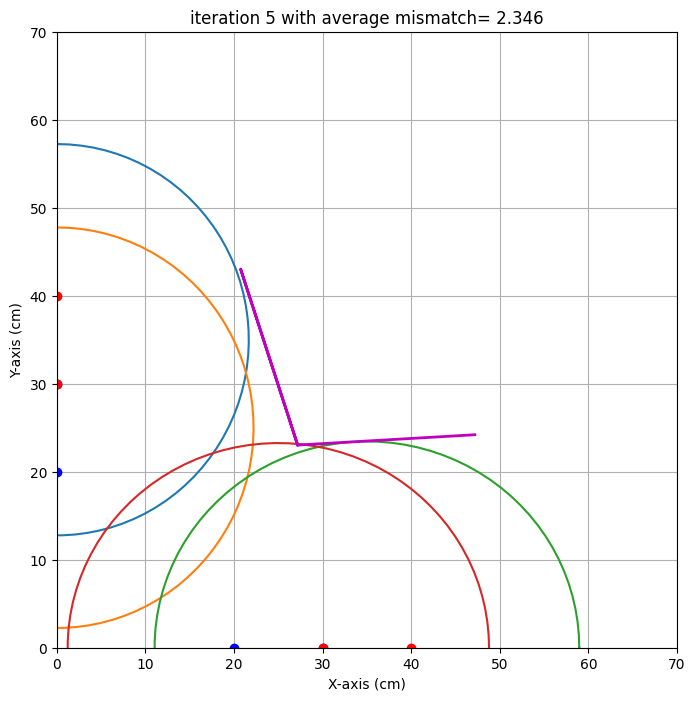

end iteration 5 with average mismatch= 2.346


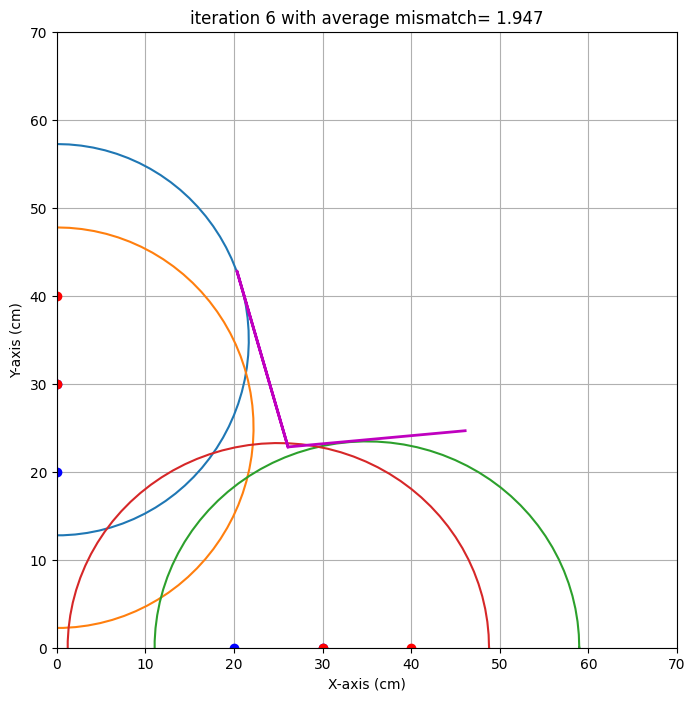

end iteration 6 with average mismatch= 1.947
end iteration 7 with average mismatch= 1.848


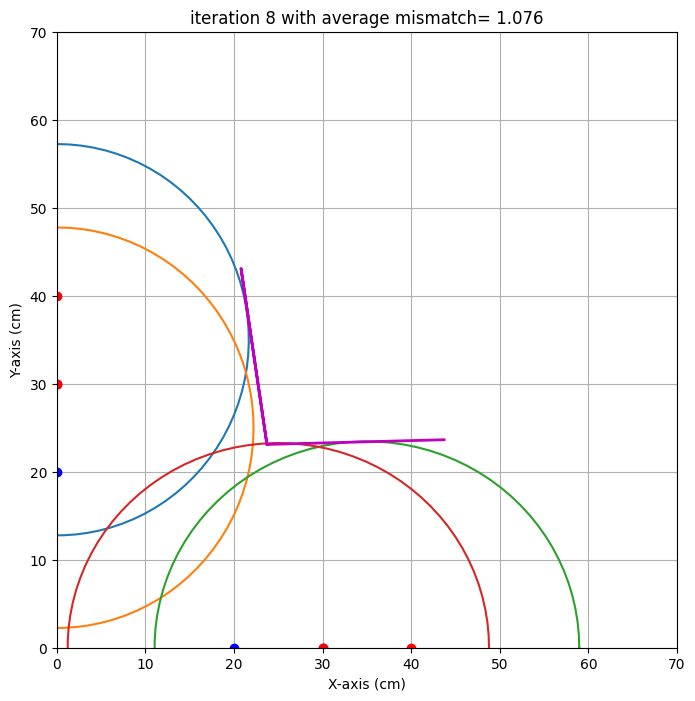

end iteration 8 with average mismatch= 1.076


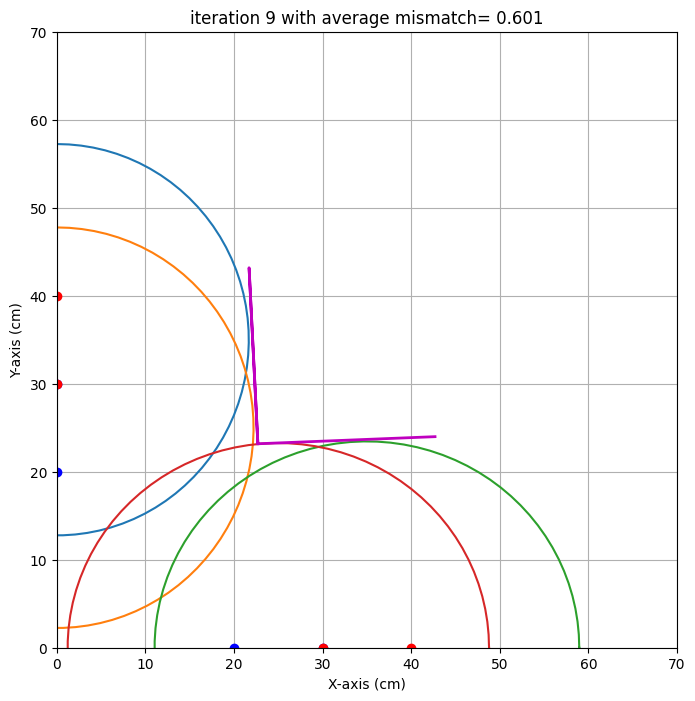

end iteration 9 with average mismatch= 0.601


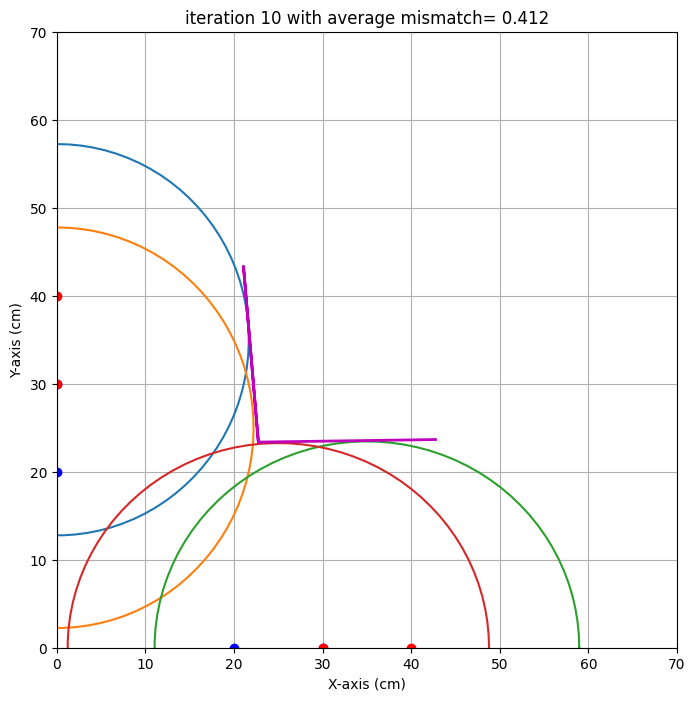

end iteration 10 with average mismatch= 0.412


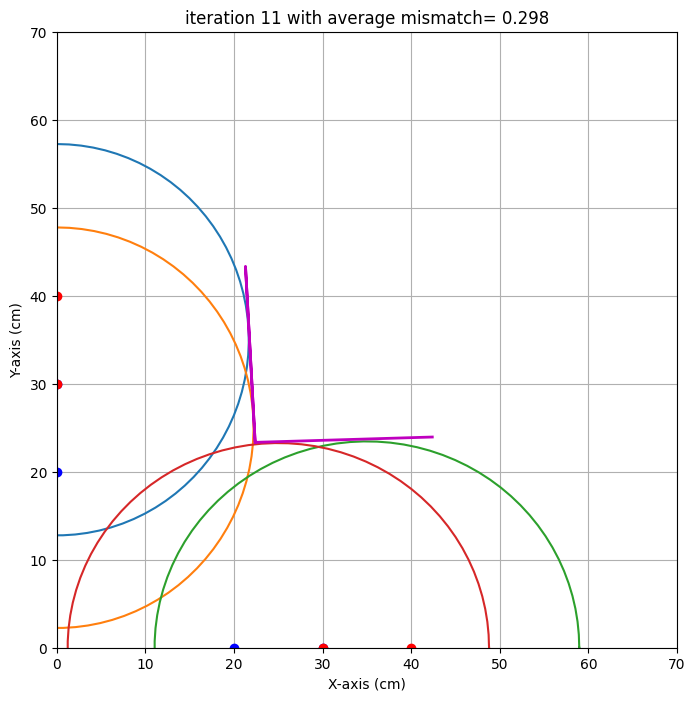

end iteration 11 with average mismatch= 0.298


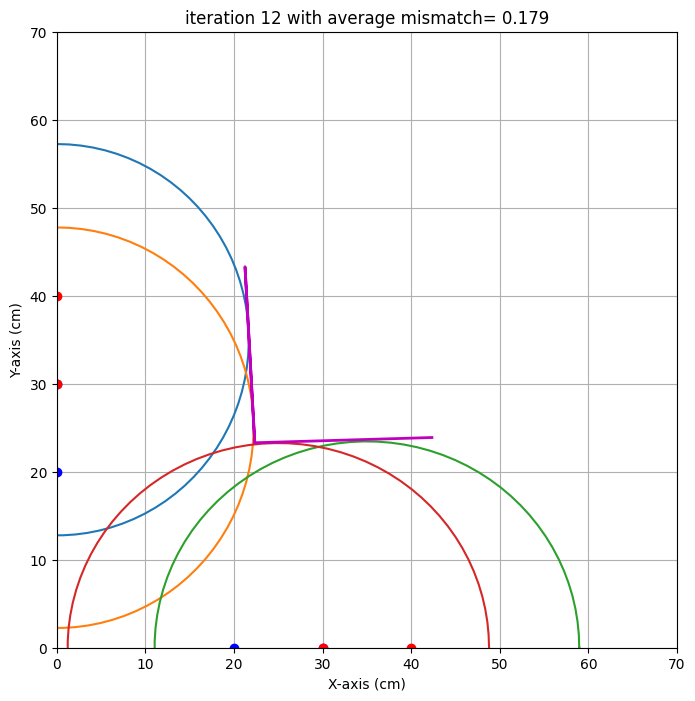

end iteration 12 with average mismatch= 0.179
end iteration 13 with average mismatch= 0.173
end iteration 14 with average mismatch= 0.173
end iteration 15 with average mismatch= 0.173
end iteration 16 with average mismatch= 0.173
end iteration 17 with average mismatch= 0.173
end iteration 18 with average mismatch= 0.173
end iteration 19 with average mismatch= 0.173
end iteration 20 with average mismatch= 0.173
end iteration 21 with average mismatch= 0.173
end iteration 22 with average mismatch= 0.173
end iteration 23 with average mismatch= 0.173
end iteration 24 with average mismatch= 0.173
end iteration 25 with average mismatch= 0.173
end iteration 26 with average mismatch= 0.173
end iteration 27 with average mismatch= 0.173
end iteration 28 with average mismatch= 0.173
end iteration 29 with average mismatch= 0.173
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch

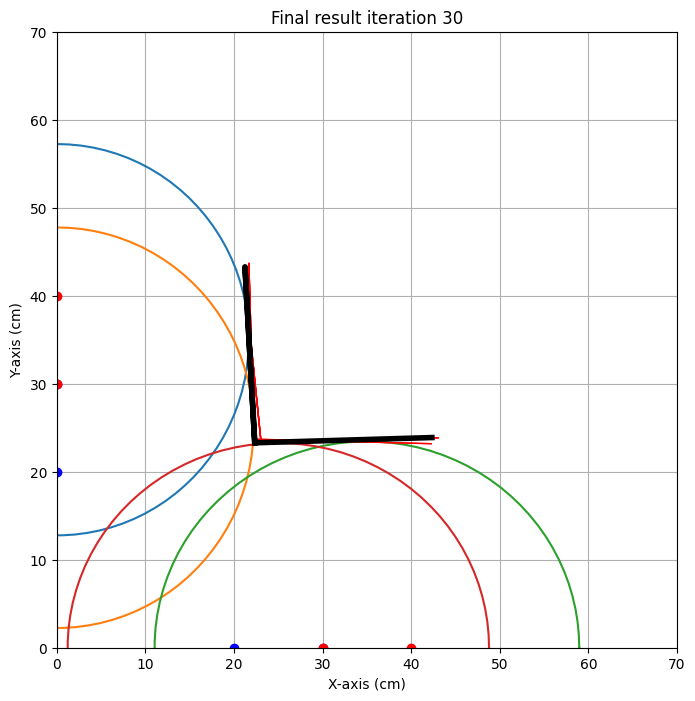

In [17]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,44.47],
    [0,30,0,20,45.52],
    #[0,10,0,20,193.37],
    [40,0,30,0,47.95],
    [30,0,20,0,47.58],
    #[10,0,20,0,190.56],
    #[10,0,0,10,191.41]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [18]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.3 cm met een standaardafwijking van 0.7 cm 
y0: 23.3 cm met een standaardafwijking van 0.4 cm 
alpha: 1.7 graden met een standaardafwijking van 3.2 graad 
beta: -3.2 graden met een standaardafwijking van 2.6 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Hugo Rutten]

Voeg een foto in van het algoritme van het eerste groepslid

<img src="SchemaHugo.jpeg" width="400">

#### algoritme [Yael Jawahierkhan]

Voeg een foto in van het algoritme van het tweede groepslid

<img src="SchemaYael.jpeg" width="400">

#### algoritme [Matteo Leonardi]

Voeg een foto in van het algoritme van het derde groepslid

<img src="SchemaMatteo.jpeg" width="400">

In [19]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [20]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 24,   
           'y0': 31,
           'alpha': 25,  
           'beta': 10,  
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Yael Jawahierkhan' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [62.4,0,52.5,0,83.5],
    [0,62.5,0,52.5,65.2],
    #[0,70,0,60,200],
    #[70,0,60,0,200],

    ]),
       'Matteo Leonardi' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    ])}

## Opdracht 7: Evaluatie.

Yael Jawahierkhan
Running the imaging algorithm with the following data:
     xs    ys    xr    yr     R
0  62.4   0.0  52.5   0.0  83.5
1   0.0  62.5   0.0  52.5  65.2


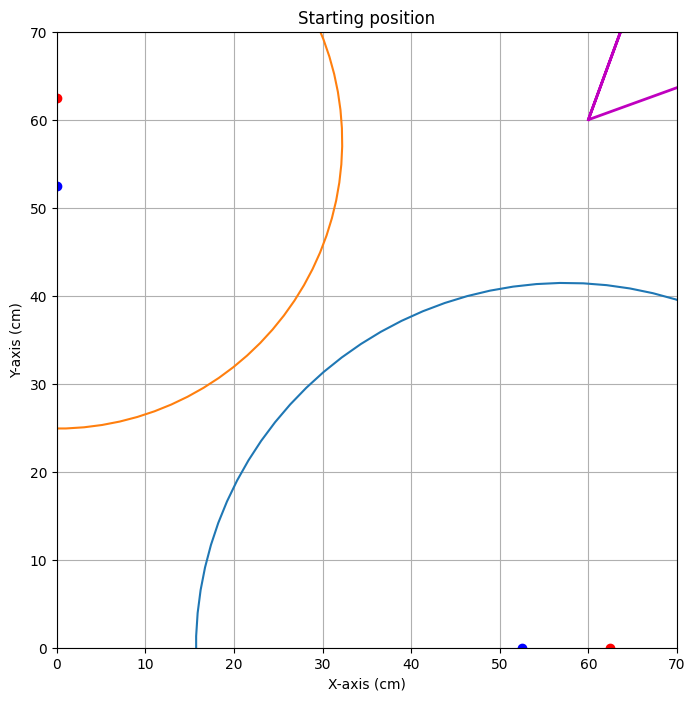


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=51.706


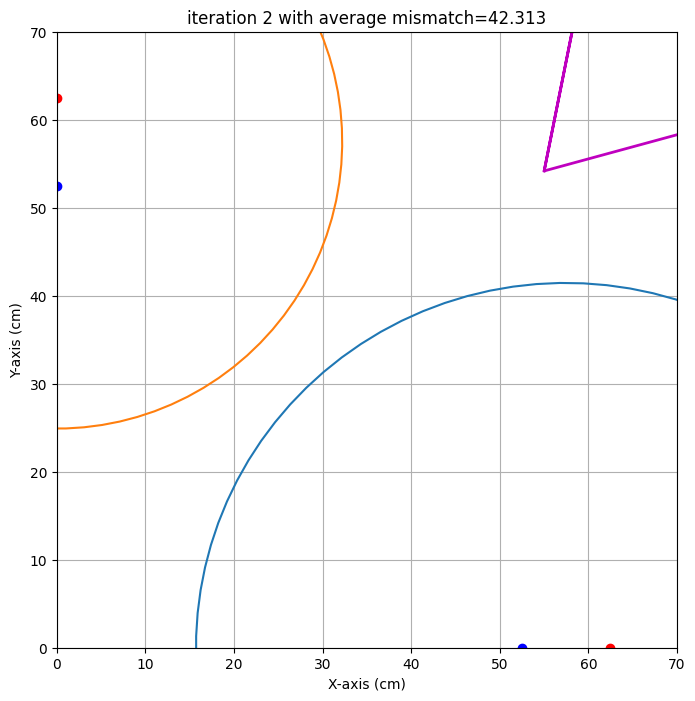

end iteration 2 with average mismatch=42.313


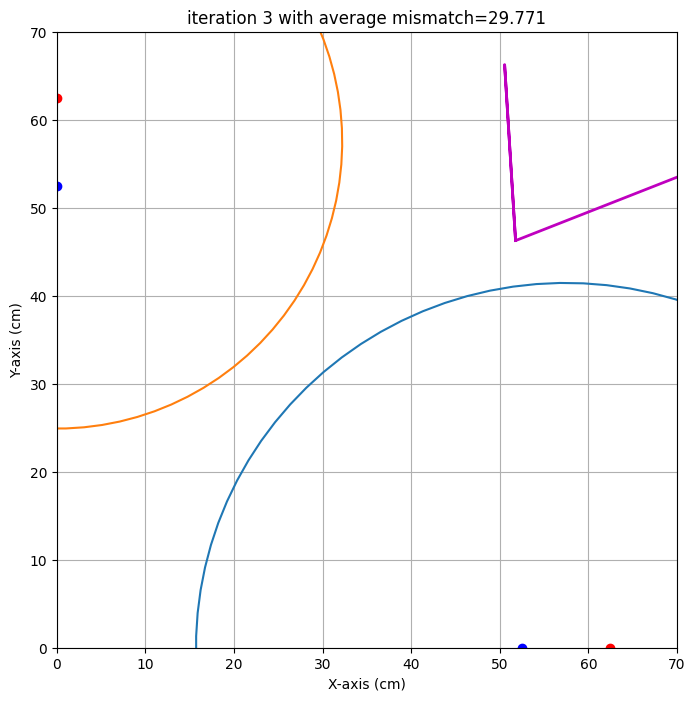

end iteration 3 with average mismatch=29.771


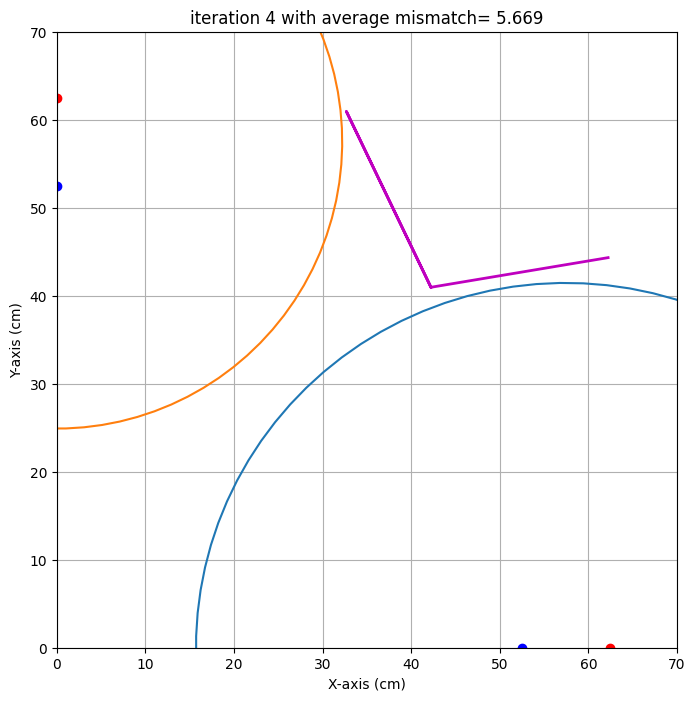

end iteration 4 with average mismatch= 5.669


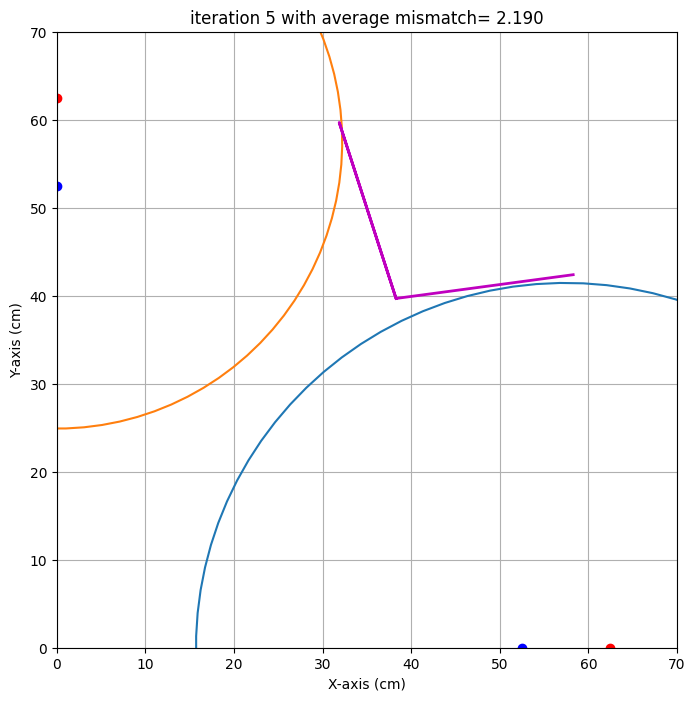

end iteration 5 with average mismatch= 2.190
end iteration 6 with average mismatch= 2.153
end iteration 7 with average mismatch= 2.113


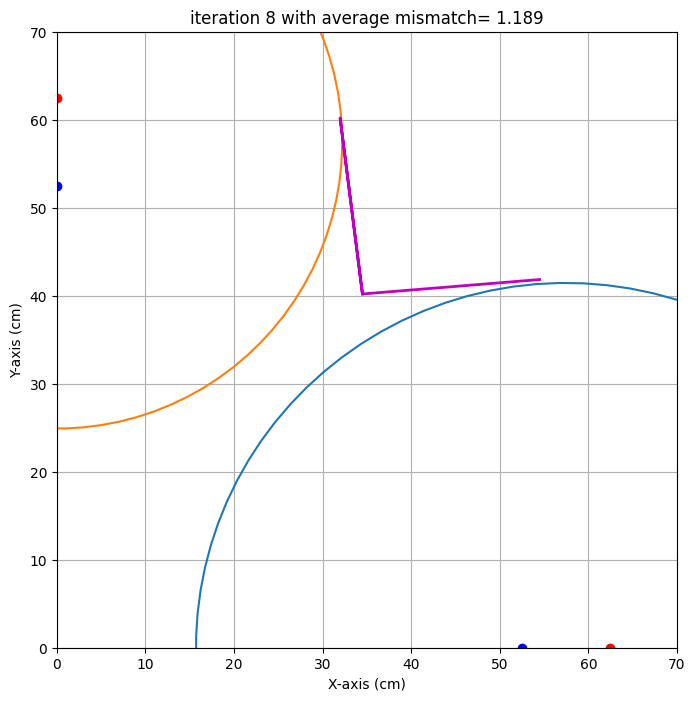

end iteration 8 with average mismatch= 1.189
end iteration 9 with average mismatch= 1.151


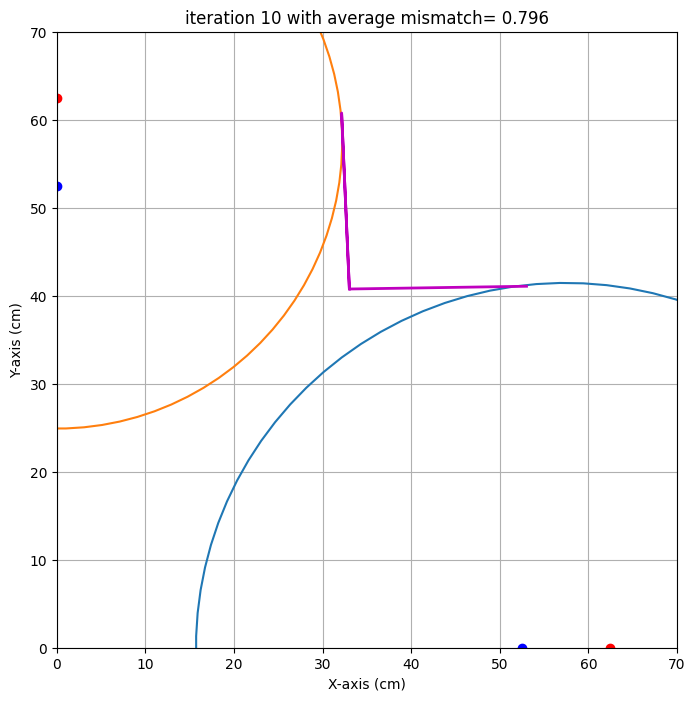

end iteration 10 with average mismatch= 0.796
end iteration 11 with average mismatch= 0.767
end iteration 12 with average mismatch= 0.753
end iteration 13 with average mismatch= 0.746


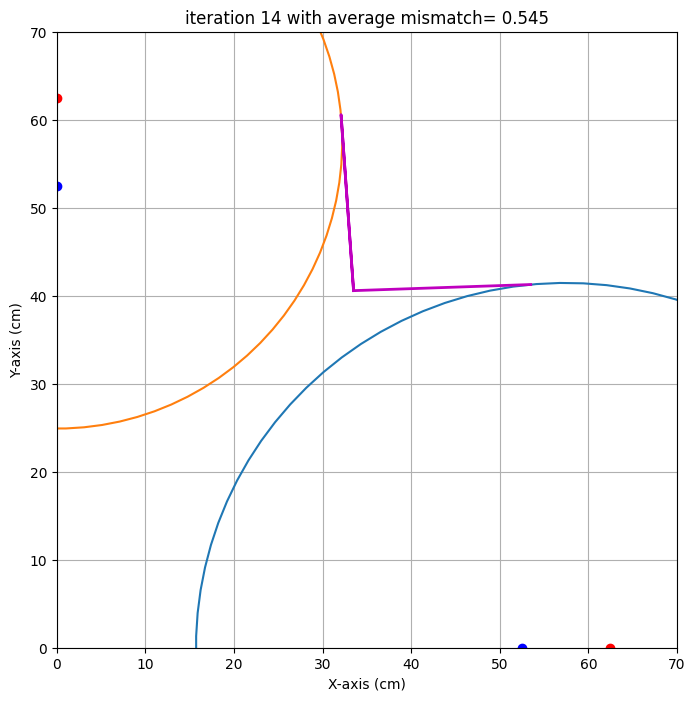

end iteration 14 with average mismatch= 0.545
end iteration 15 with average mismatch= 0.544
end iteration 16 with average mismatch= 0.544
end iteration 17 with average mismatch= 0.544
end iteration 18 with average mismatch= 0.544


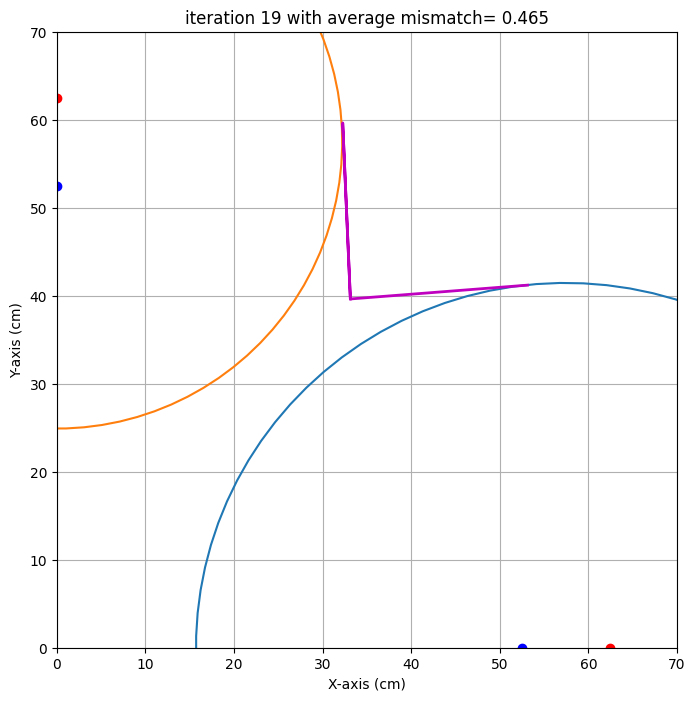

end iteration 19 with average mismatch= 0.465
end iteration 20 with average mismatch= 0.438


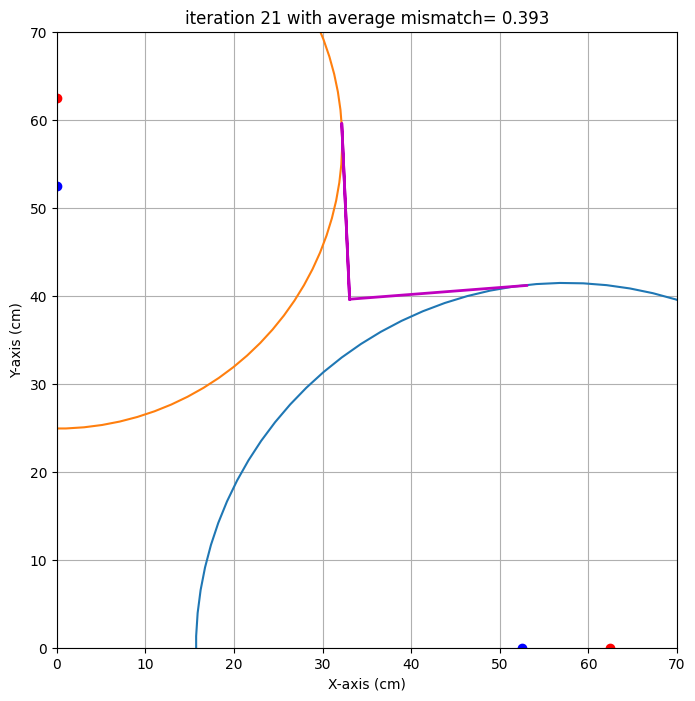

end iteration 21 with average mismatch= 0.393
end iteration 22 with average mismatch= 0.387


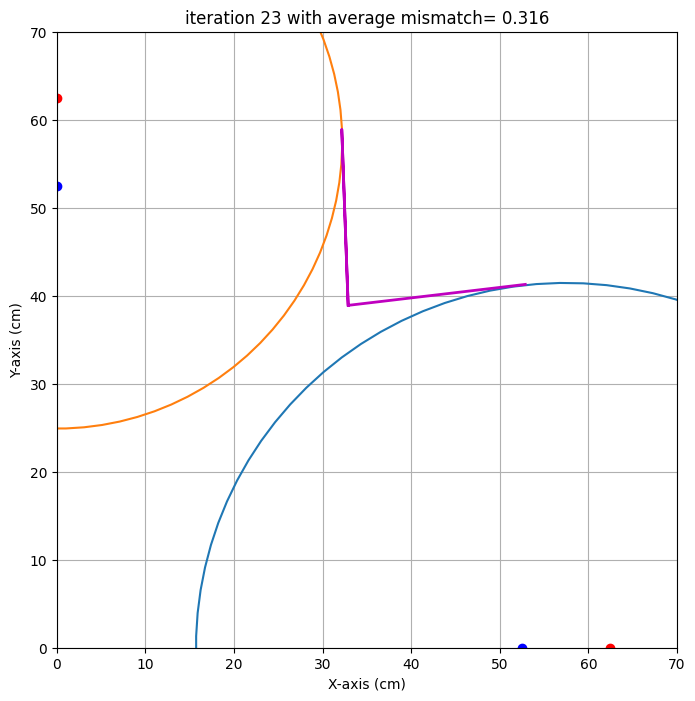

end iteration 23 with average mismatch= 0.316
end iteration 24 with average mismatch= 0.316


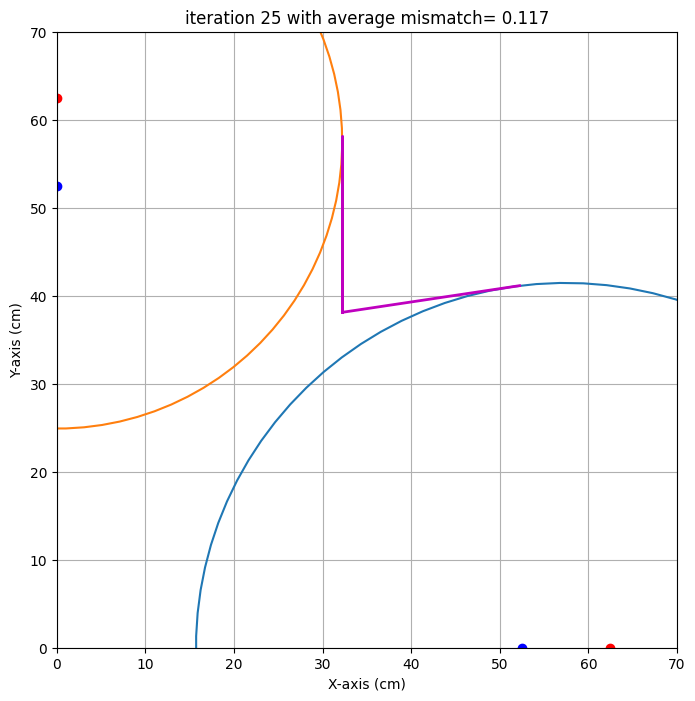

end iteration 25 with average mismatch= 0.117


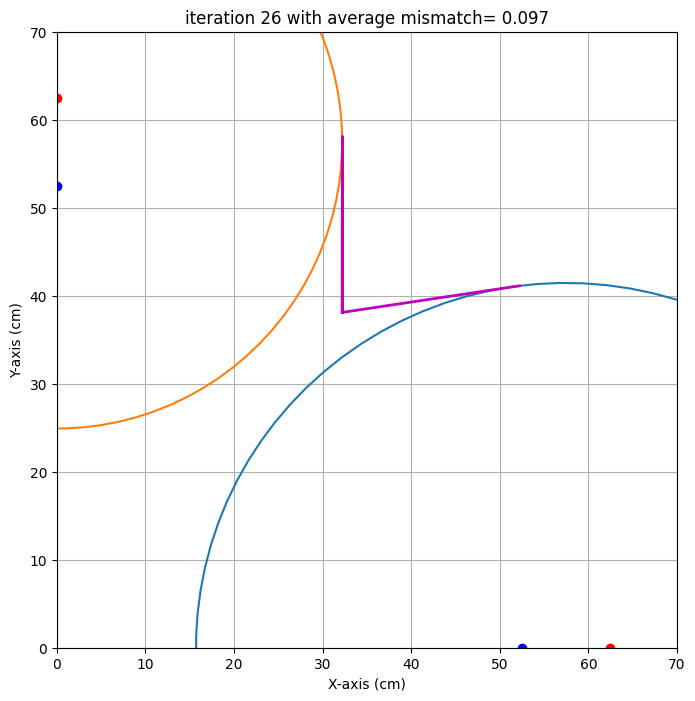

end iteration 26 with average mismatch= 0.097


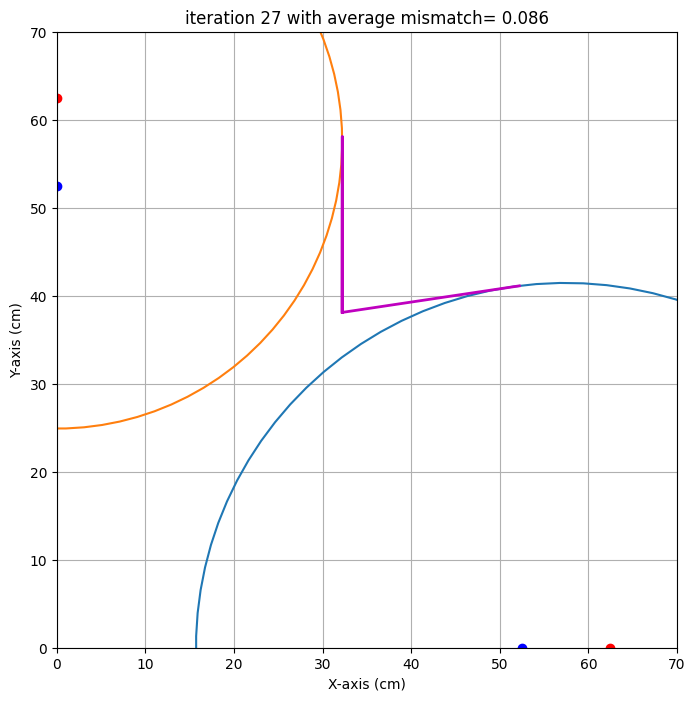

end iteration 27 with average mismatch= 0.086
end iteration 28 with average mismatch= 0.080
end iteration 29 with average mismatch= 0.078
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.078
###############################################################################
end of iteration  30
Best alpha=   8.58 with uncertainty=   7.80
Best beta =   0.04 with uncertainty=  11.08
Best x0   =  32.20 with uncertainty=   3.62
Best y0   =  38.10 with uncertainty=   3.04
###############################################################################


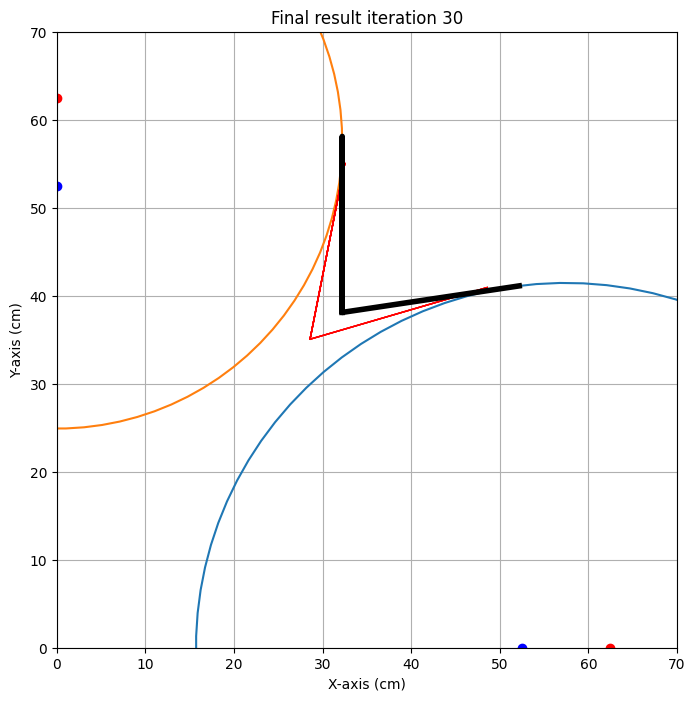

{'alpha': np.float64(8.575933888101765), 'alpha_eps': np.float64(7.804764960633232), 'beta': np.float64(0.04182153182524806), 'beta_eps': np.float64(11.077361452732772), 'x0': np.float64(32.19729251322116), 'x0_eps': np.float64(3.6164477068248218), 'y0': np.float64(38.101726100186845), 'y0_eps': np.float64(3.0448277238718404)}
Matteo Leonardi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2


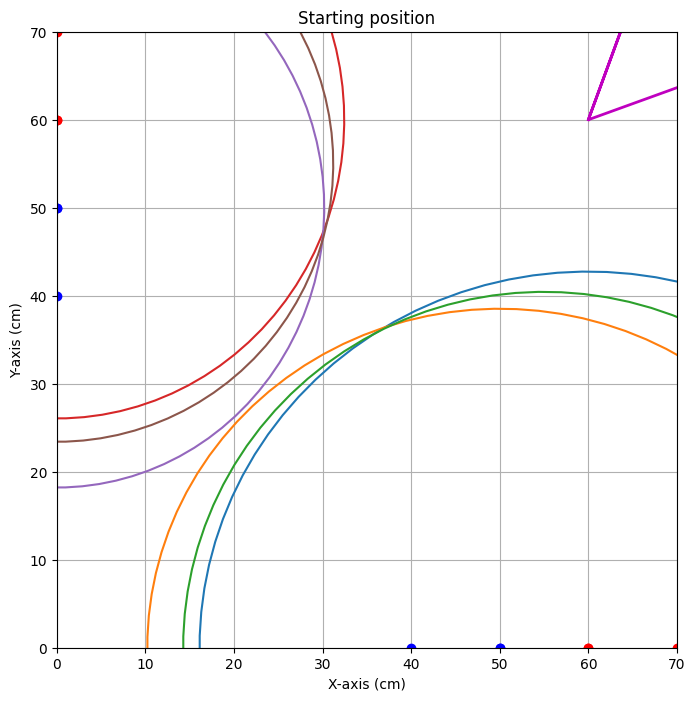


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.671


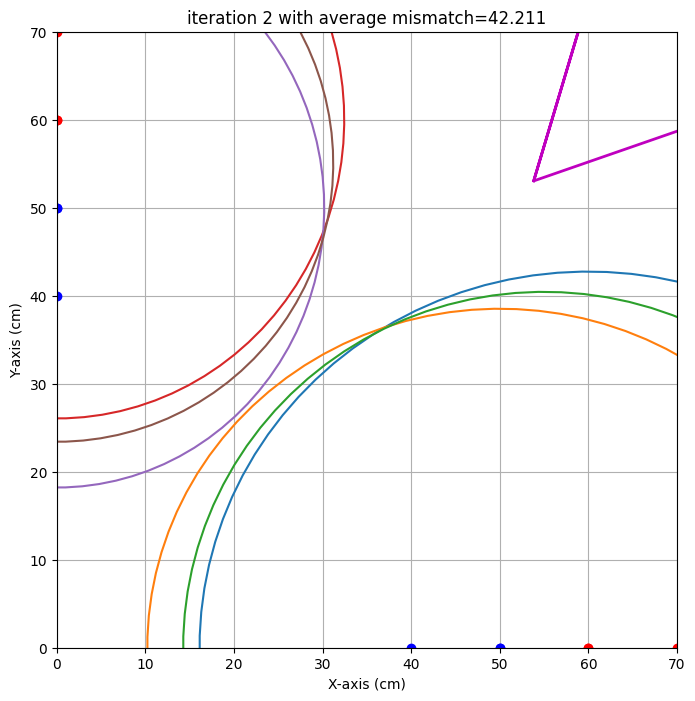

end iteration 2 with average mismatch=42.211


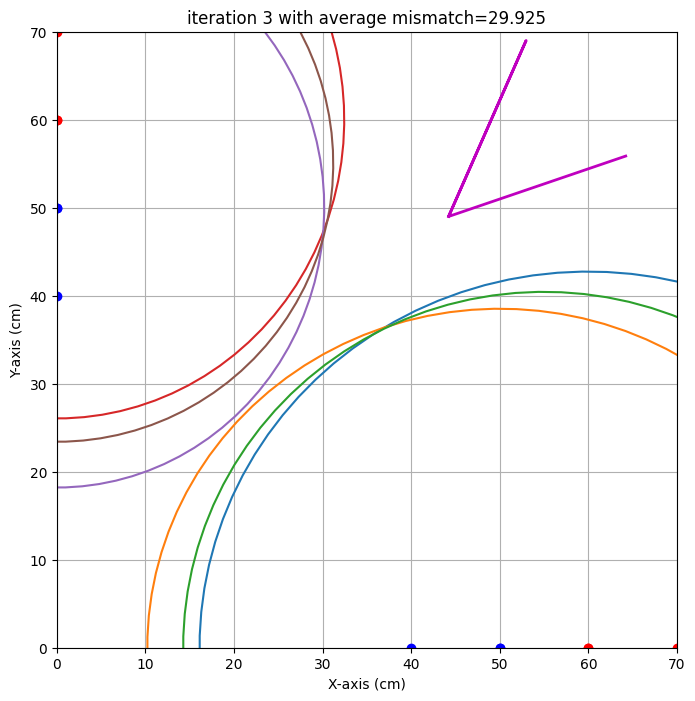

end iteration 3 with average mismatch=29.925


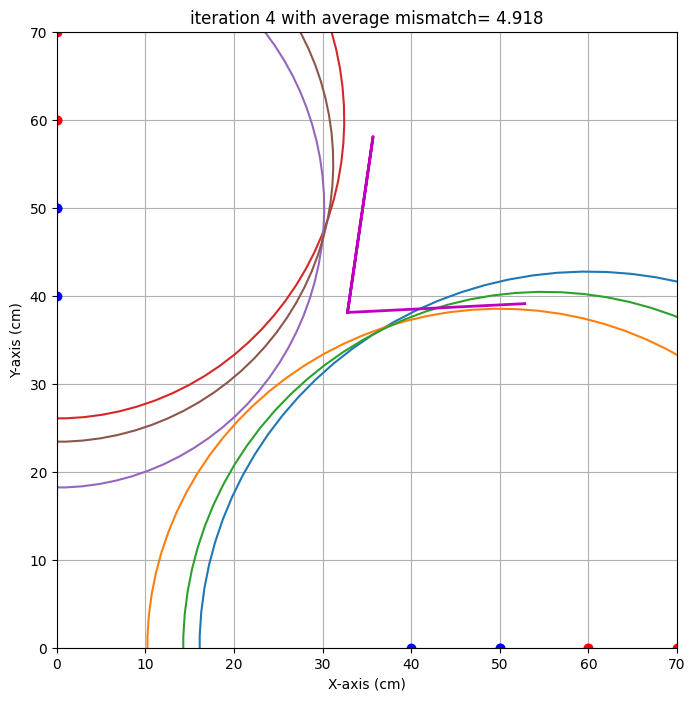

end iteration 4 with average mismatch= 4.918


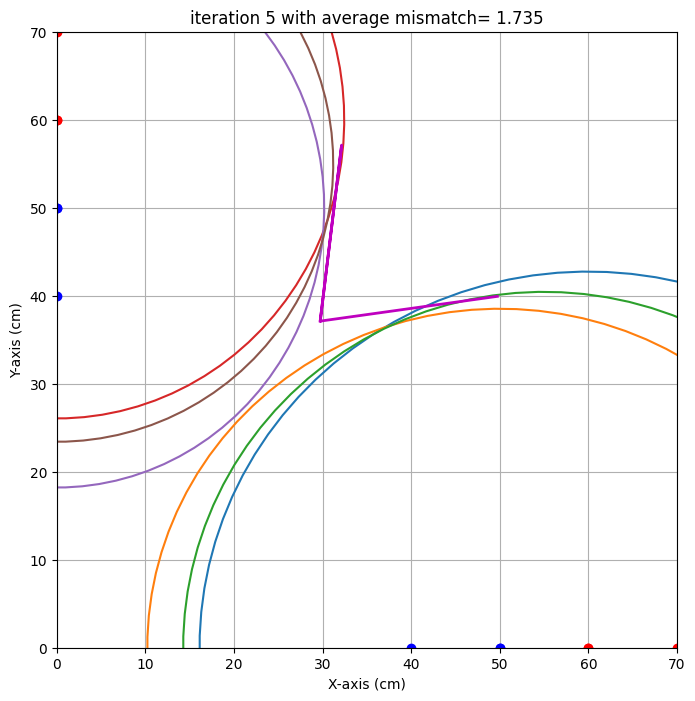

end iteration 5 with average mismatch= 1.735


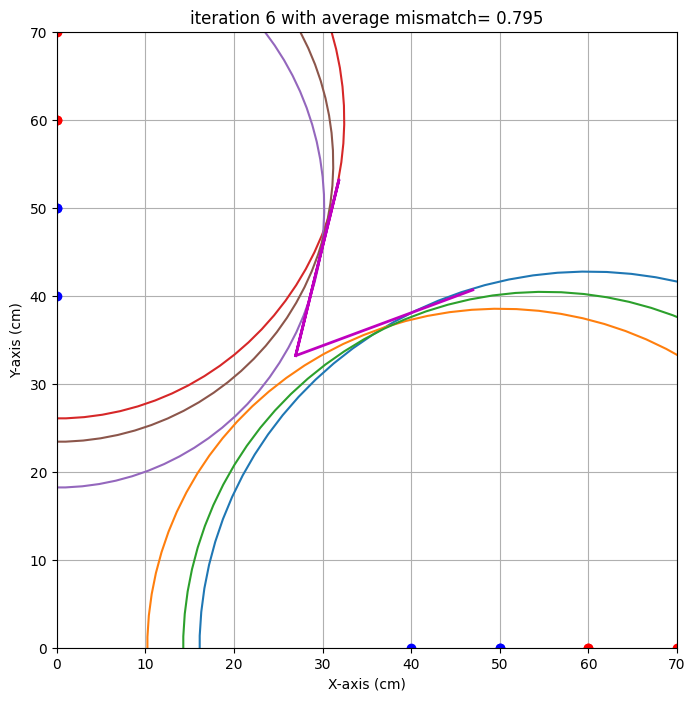

end iteration 6 with average mismatch= 0.795
end iteration 7 with average mismatch= 0.772


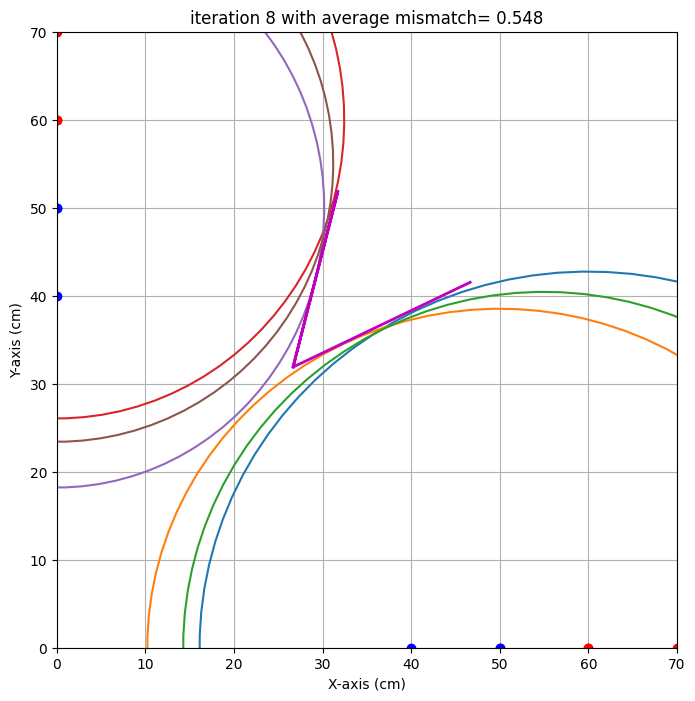

end iteration 8 with average mismatch= 0.548
end iteration 9 with average mismatch= 0.520
end iteration 10 with average mismatch= 0.496
end iteration 11 with average mismatch= 0.493
end iteration 12 with average mismatch= 0.492
end iteration 13 with average mismatch= 0.492
end iteration 14 with average mismatch= 0.492
end iteration 15 with average mismatch= 0.492
end iteration 16 with average mismatch= 0.476
end iteration 17 with average mismatch= 0.437
end iteration 18 with average mismatch= 0.437
end iteration 19 with average mismatch= 0.437
end iteration 20 with average mismatch= 0.437
end iteration 21 with average mismatch= 0.437
end iteration 22 with average mismatch= 0.437
end iteration 23 with average mismatch= 0.437
end iteration 24 with average mismatch= 0.427
end iteration 25 with average mismatch= 0.425
end iteration 26 with average mismatch= 0.405
end iteration 27 with average mismatch= 0.403
end iteration 28 with average mismatch= 0.403
end iteration 29 with average mismat

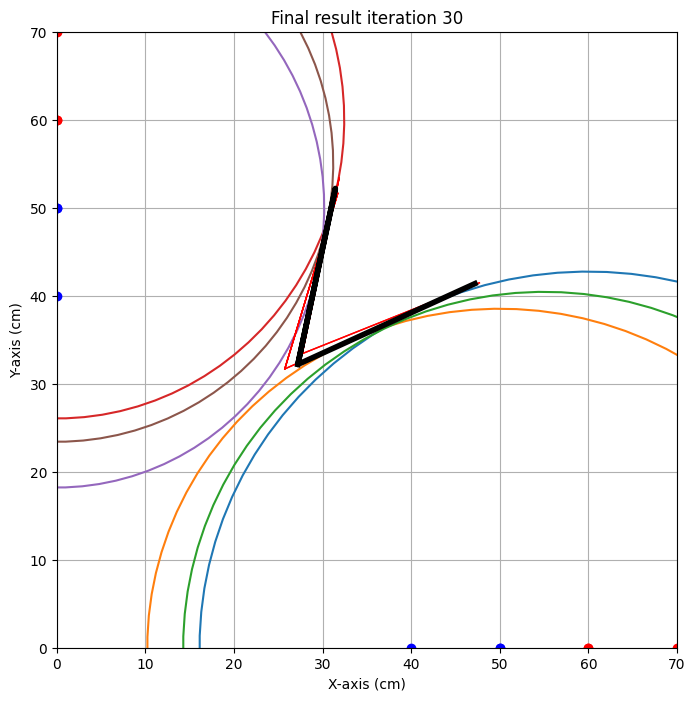

{'alpha': np.float64(24.667246207060863), 'alpha_eps': np.float64(2.732380129767545), 'beta': np.float64(11.969958497435963), 'beta_eps': np.float64(4.721779080613457), 'x0': np.float64(27.201365654464347), 'x0_eps': np.float64(1.474632189603529), 'y0': np.float64(32.19249654278719), 'y0_eps': np.float64(1.221481707376995)}


In [21]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [22]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Yael Jawahierkhan 
x0 target is : 24.0. Gevonden waarde: 32.2 cm met een standaardafwijking van 3.6 cm 
y0 target is : 31.0. Gevonden waarde: 38.1 cm met een standaardafwijking van 3.0 cm 
alpha target is : 25.0. Gevonden waarde: 8.6 graden met een standaardafwijking van 7.8 graad 
beta target is : 10.0. Gevonden waarde: 0.0 graden met een standaardafwijking van 11.1 graad 

Matteo Leonardi 
x0 target is : 24.0. Gevonden waarde: 27.2 cm met een standaardafwijking van 1.5 cm 
y0 target is : 31.0. Gevonden waarde: 32.2 cm met een standaardafwijking van 1.2 cm 
alpha target is : 25.0. Gevonden waarde: 24.7 graden met een standaardafwijking van 2.7 graad 
beta target is : 10.0. Gevonden waarde: 12.0 graden met een standaardafwijking van 4.7 graad 



## Opdracht 8: Iteratie1+. 14:49.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: 

![Alt](Iteratie1.jpeg)


In [23]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2
6  70   0  40   0  84.4
7   0  70   0  40  68.7


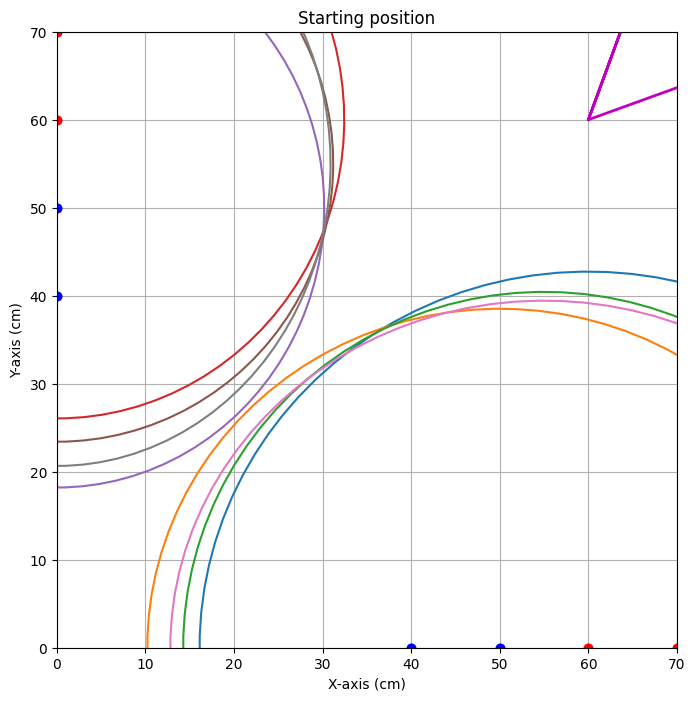


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.529


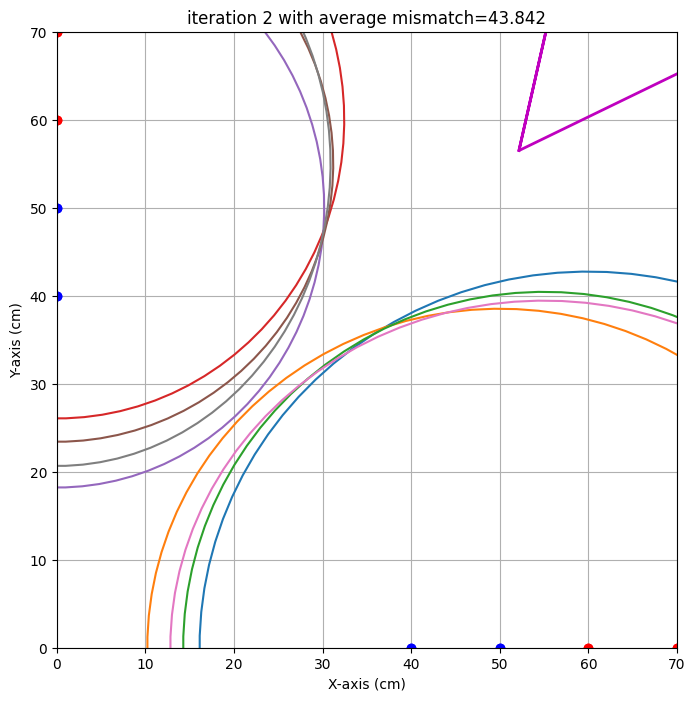

end iteration 2 with average mismatch=43.842


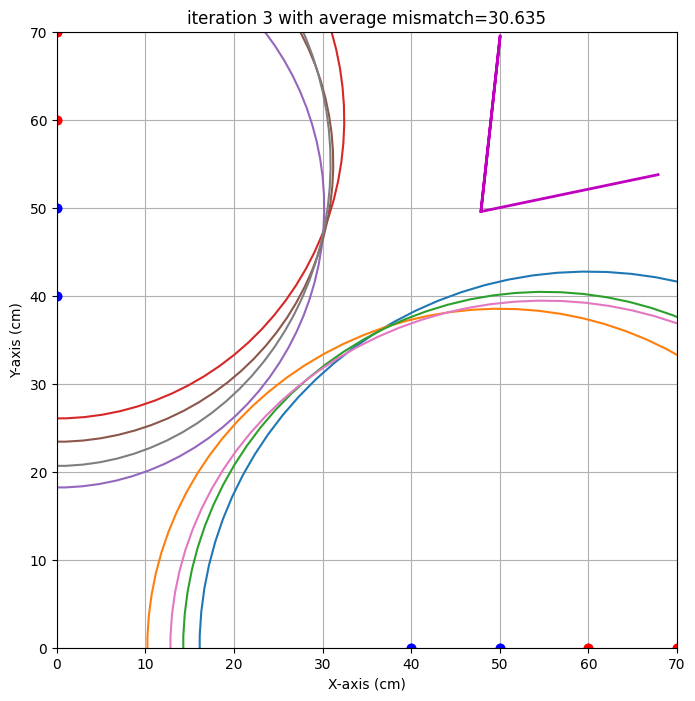

end iteration 3 with average mismatch=30.635


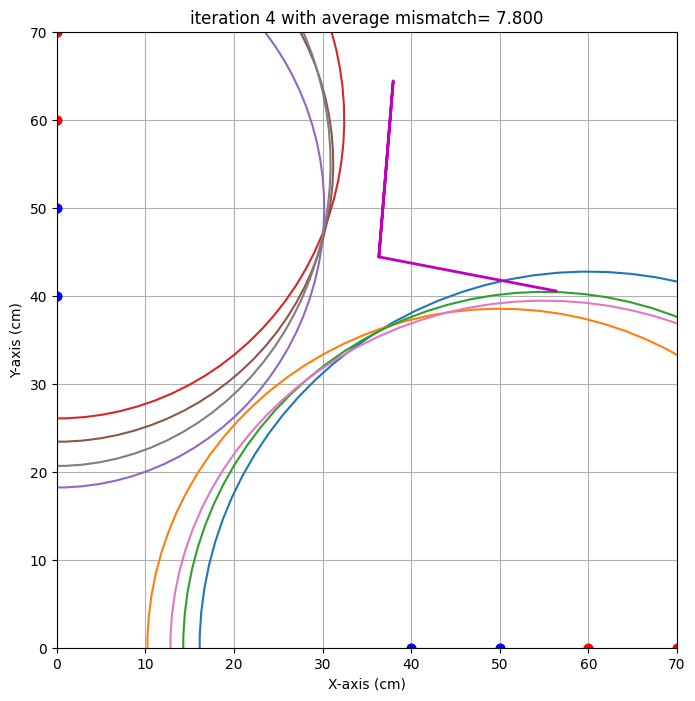

end iteration 4 with average mismatch= 7.800


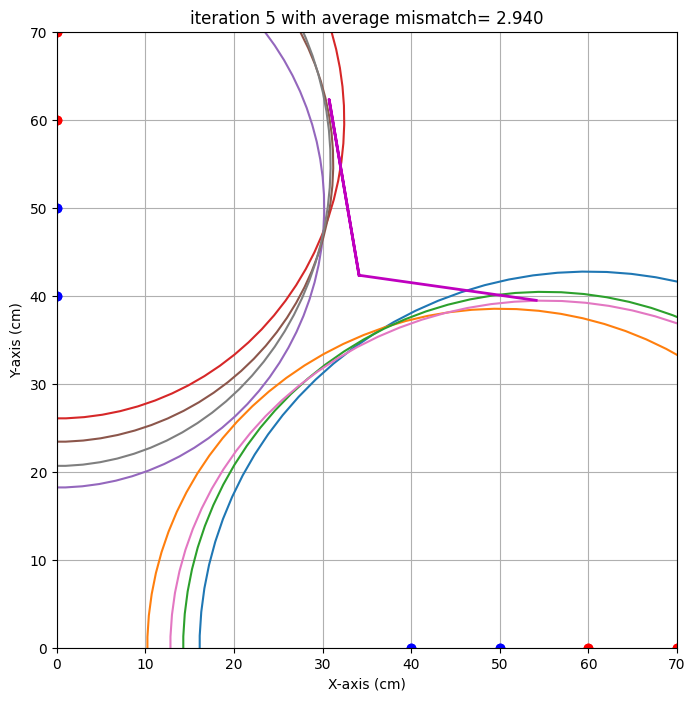

end iteration 5 with average mismatch= 2.940


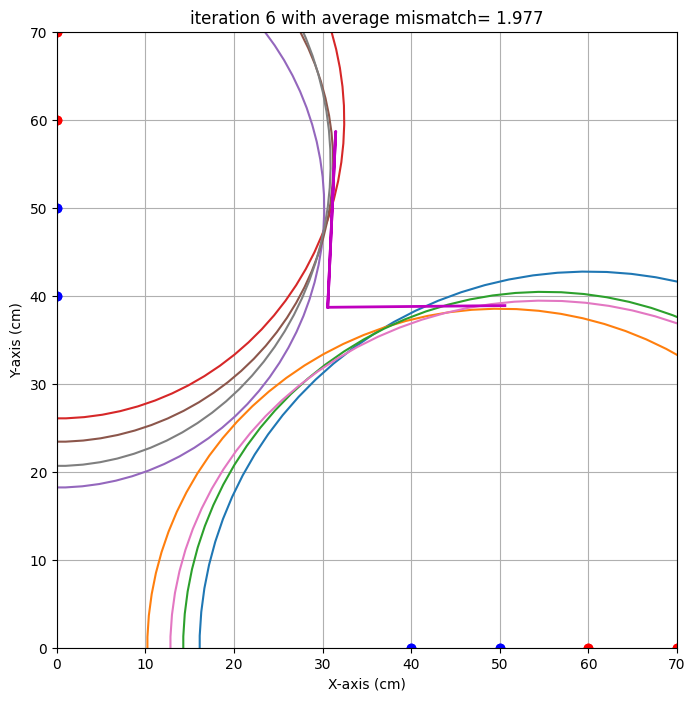

end iteration 6 with average mismatch= 1.977


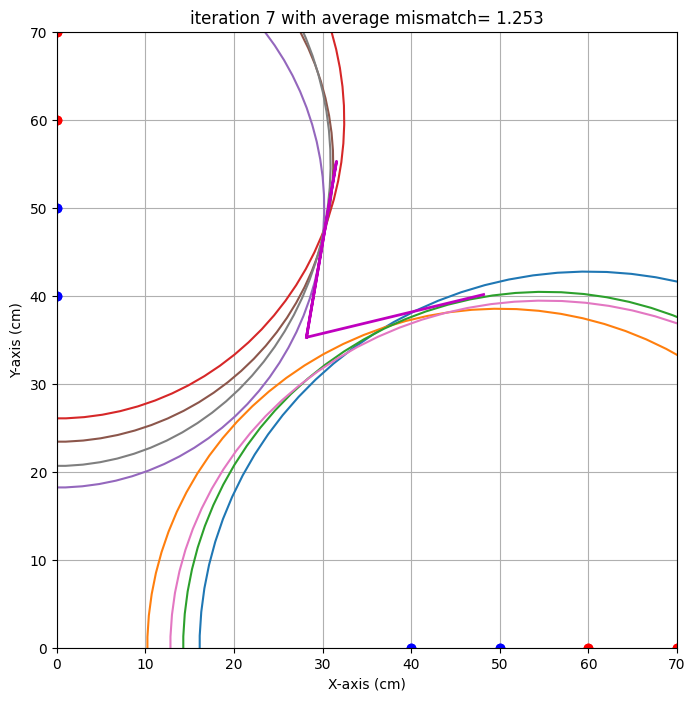

end iteration 7 with average mismatch= 1.253


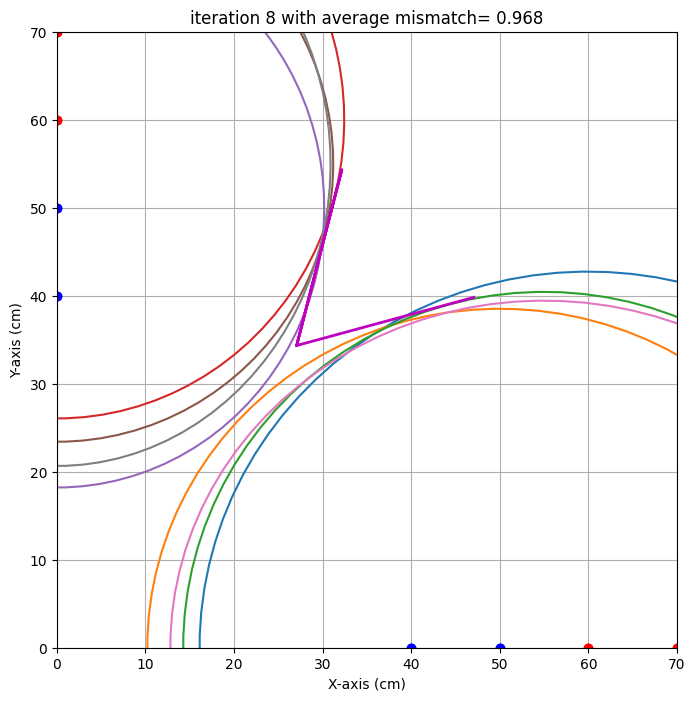

end iteration 8 with average mismatch= 0.968
end iteration 9 with average mismatch= 0.912
end iteration 10 with average mismatch= 0.859


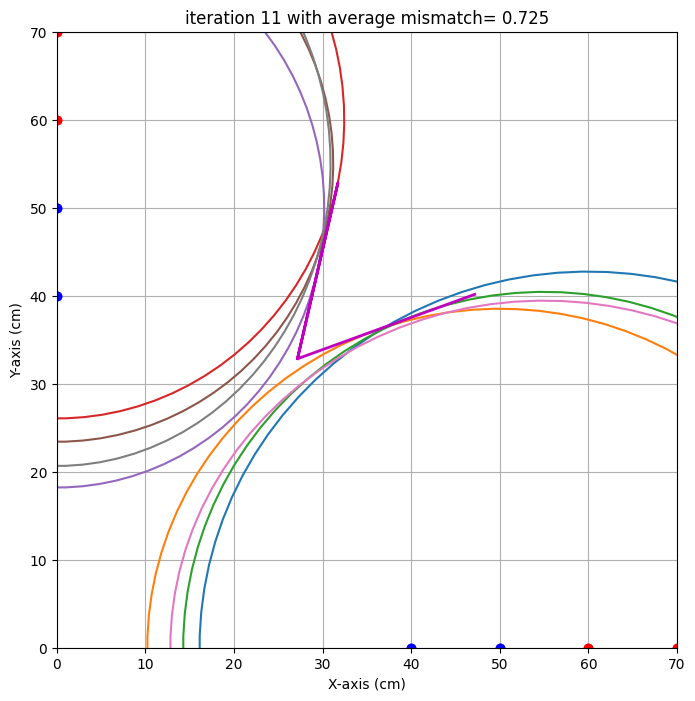

end iteration 11 with average mismatch= 0.725
end iteration 12 with average mismatch= 0.722
end iteration 13 with average mismatch= 0.716
end iteration 14 with average mismatch= 0.714
end iteration 15 with average mismatch= 0.714
end iteration 16 with average mismatch= 0.713
end iteration 17 with average mismatch= 0.713
end iteration 18 with average mismatch= 0.713
end iteration 19 with average mismatch= 0.713
end iteration 20 with average mismatch= 0.713
end iteration 21 with average mismatch= 0.713
end iteration 22 with average mismatch= 0.713
end iteration 23 with average mismatch= 0.713
end iteration 24 with average mismatch= 0.713
end iteration 25 with average mismatch= 0.713
end iteration 26 with average mismatch= 0.713
end iteration 27 with average mismatch= 0.713
end iteration 28 with average mismatch= 0.713
end iteration 29 with average mismatch= 0.713
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

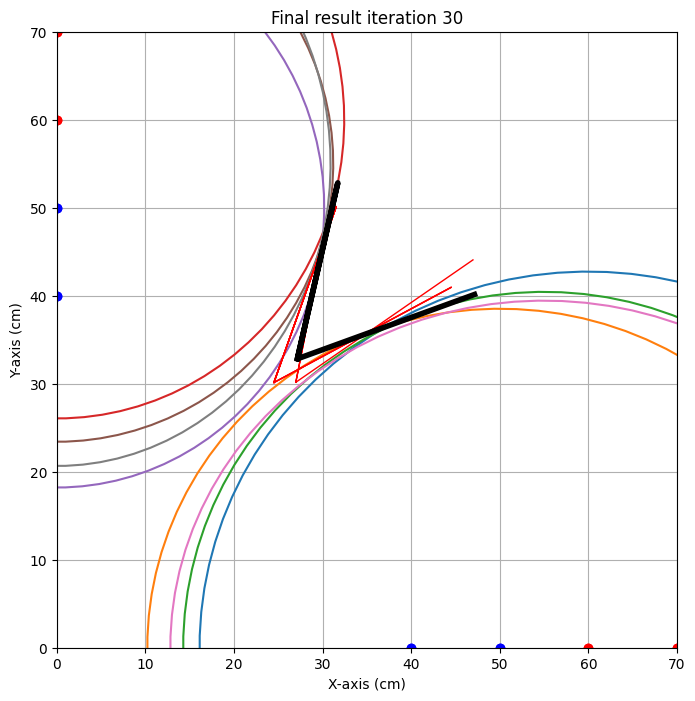

{'alpha': np.float64(20.08108232139503), 'alpha_eps': np.float64(14.735907762589306), 'beta': np.float64(12.863938519871768), 'beta_eps': np.float64(6.534722640847155), 'x0': np.float64(27.14769016283774), 'x0_eps': np.float64(2.647276061127485), 'y0': np.float64(32.82847804667837), 'y0_eps': np.float64(2.6965168236466965)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


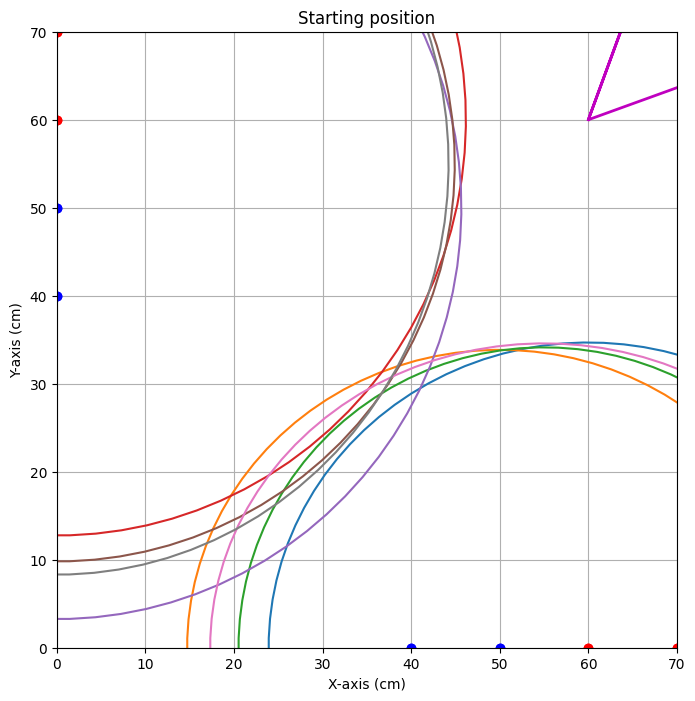


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


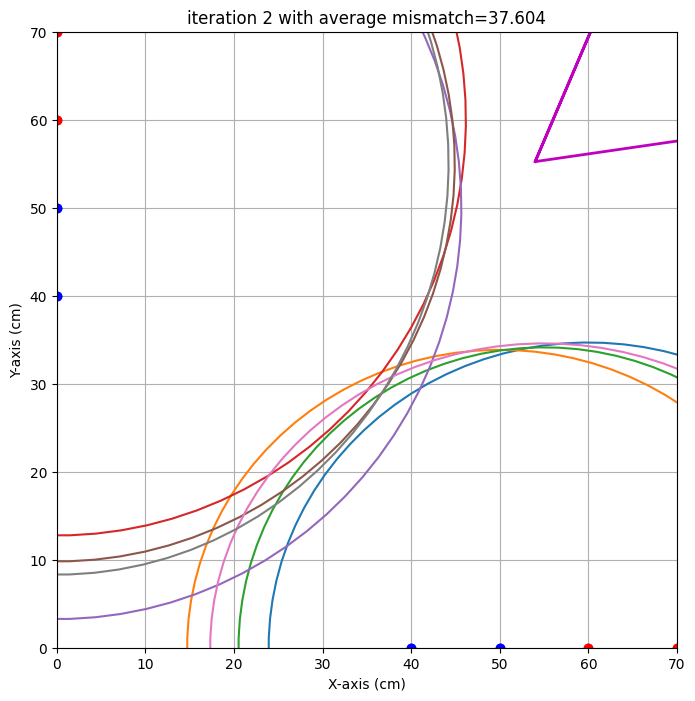

end iteration 2 with average mismatch=37.604


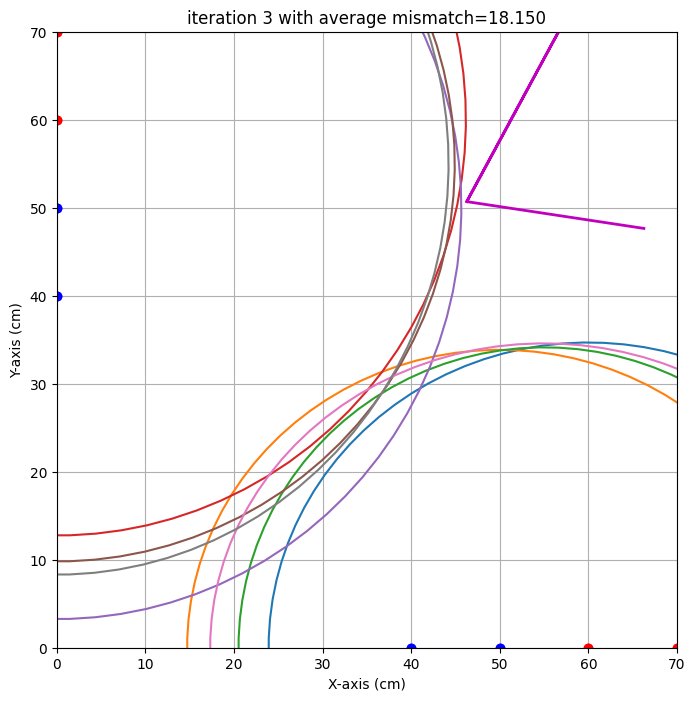

end iteration 3 with average mismatch=18.150


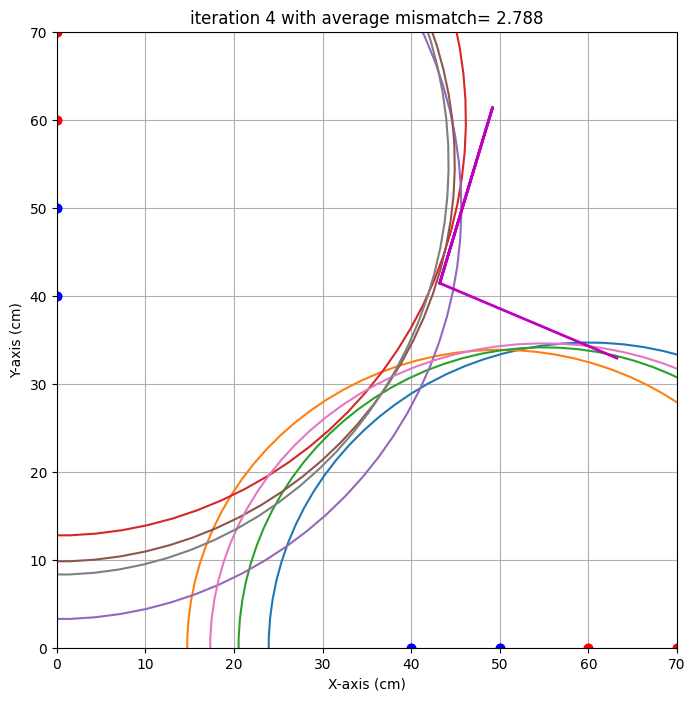

end iteration 4 with average mismatch= 2.788


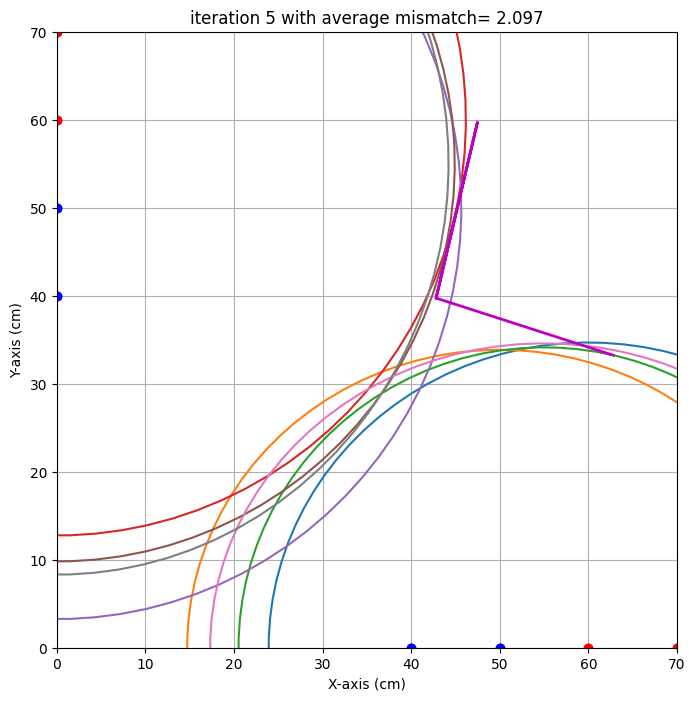

end iteration 5 with average mismatch= 2.097
end iteration 6 with average mismatch= 1.973


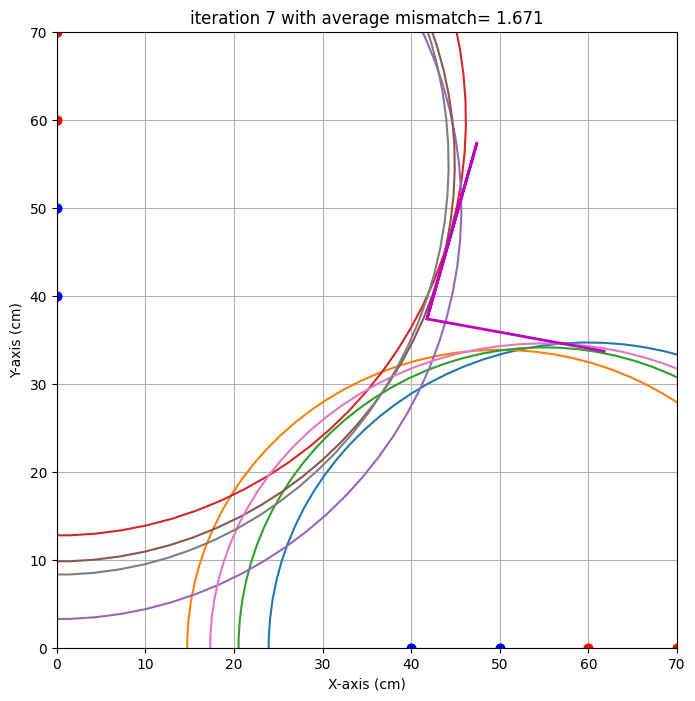

end iteration 7 with average mismatch= 1.671
end iteration 8 with average mismatch= 1.523
end iteration 9 with average mismatch= 1.520
end iteration 10 with average mismatch= 1.443


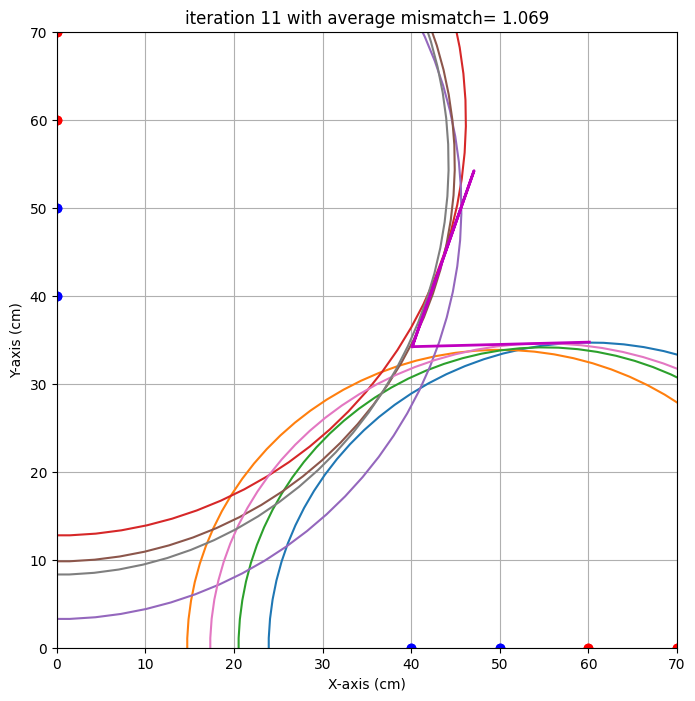

end iteration 11 with average mismatch= 1.069
end iteration 12 with average mismatch= 1.043


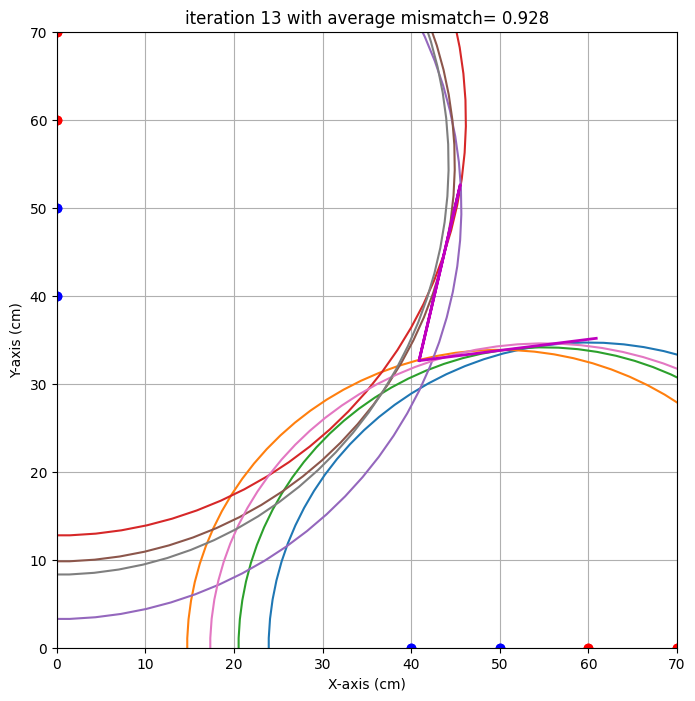

end iteration 13 with average mismatch= 0.928


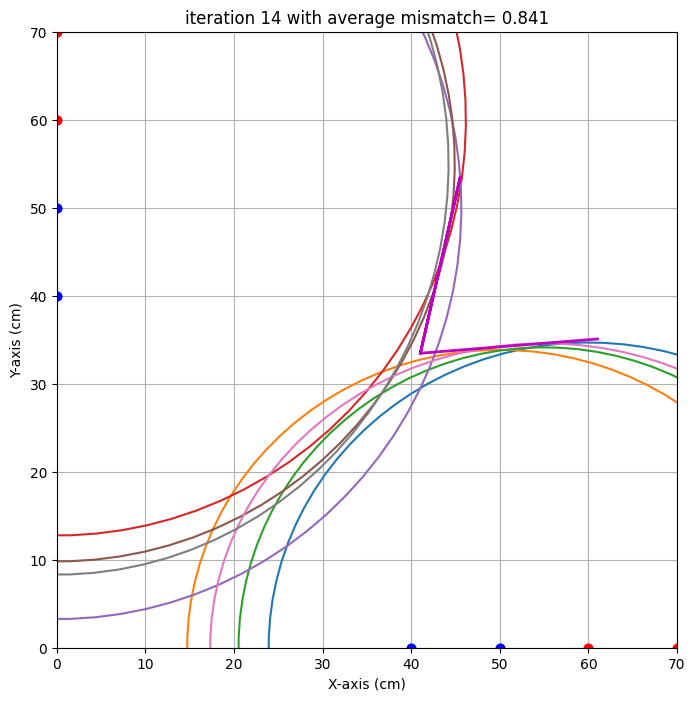

end iteration 14 with average mismatch= 0.841


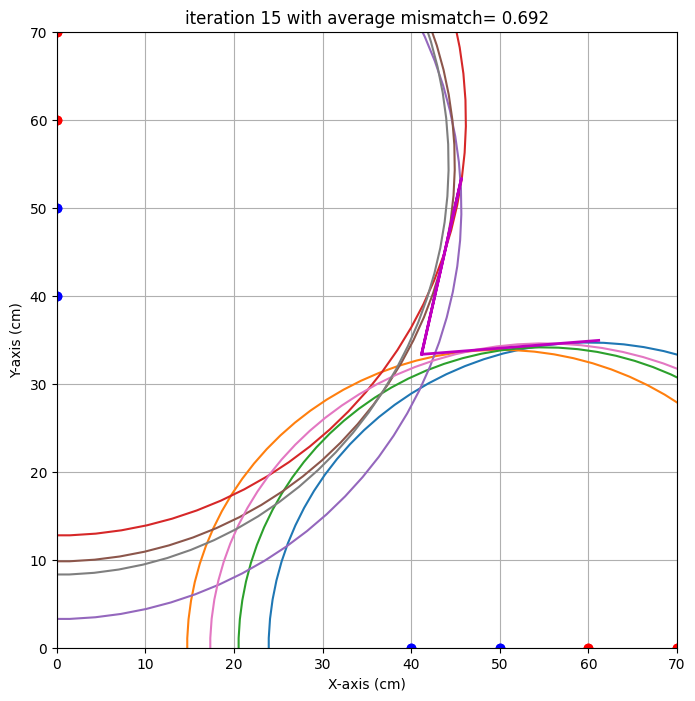

end iteration 15 with average mismatch= 0.692
end iteration 16 with average mismatch= 0.687
end iteration 17 with average mismatch= 0.686
end iteration 18 with average mismatch= 0.686
end iteration 19 with average mismatch= 0.686
end iteration 20 with average mismatch= 0.686
end iteration 21 with average mismatch= 0.686
end iteration 22 with average mismatch= 0.686
end iteration 23 with average mismatch= 0.686
end iteration 24 with average mismatch= 0.686
end iteration 25 with average mismatch= 0.686
end iteration 26 with average mismatch= 0.686
end iteration 27 with average mismatch= 0.686
end iteration 28 with average mismatch= 0.686
end iteration 29 with average mismatch= 0.686
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.686
###############################################################################
end of iteration  30
Best alpha=   4.53 with uncertainty=   4.80
Best beta 

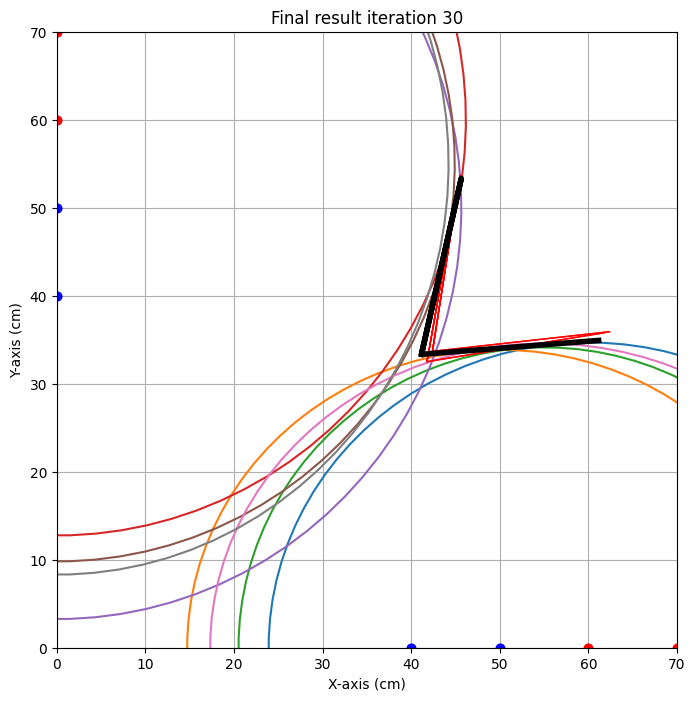

{'alpha': np.float64(4.52718072442123), 'alpha_eps': np.float64(4.797551029292537), 'beta': np.float64(12.673278911315903), 'beta_eps': np.float64(3.8372094629198763), 'x0': np.float64(41.15942430142714), 'x0_eps': np.float64(1.2396544534872902), 'y0': np.float64(33.336068850979004), 'y0_eps': np.float64(0.8288077048995177)}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 27.1 cm met een standaardafwijking van 2.6 cm 
y0 target is : 31.0. Gevonden waarde: 32.8 cm met een standaardafwijking van 2.7 cm 
alpha target is : 25.0. Gevonden waarde: 20.1 graden met een standaardafwijking van 14.7 graad 
beta target is : 10.0. Gevonden waarde: 12.9 graden met een standaardafwijking van 6.5 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.2 cm met een standaardafwijking van 1.2 cm 
y0 target is : 32.9. Gevonden waarde: 33.3 cm met een standaardafwijking van 0.8 cm 
alpha target is : 4.0. Gevonden waarde: 4.5 graden met een standaardafwijking van 4.8 graad 
beta target is : 23.0. Gevo

In [24]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 24,
                    'y0': 31,
                    'alpha' : 25,
                    'beta' : 10},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    [70,0,40,0,84.4],
    [0,70,0,40,68.7],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Iteratie 2:

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  88.6
1   70   0  70   0  93.6
2   60   0  50   0  86.5
3   65   0  55   0  88.6
4   70   0  55   0  93.3
5   65   0  50   0  88.3
6    0  70   0  50  75.5
7    0  60   0  40  69.5
8    0  60   0  50  66.8
9    0  70   0  40  74.0
10   0  65   0  45  66.1
11   0  70   0  45  69.8


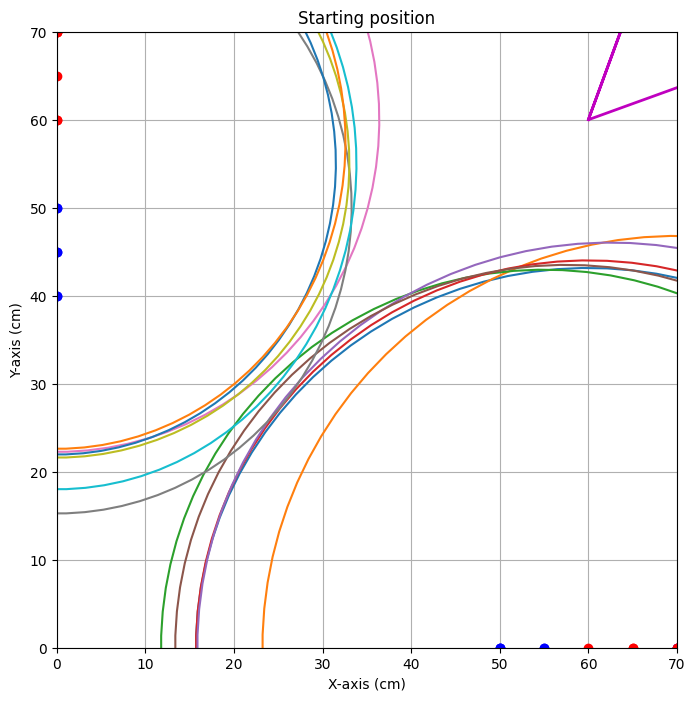


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.308


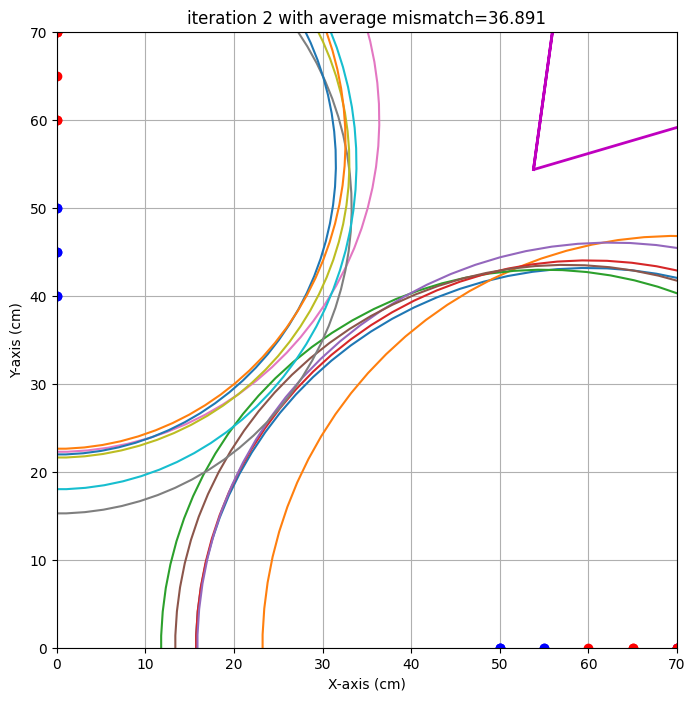

end iteration 2 with average mismatch=36.891


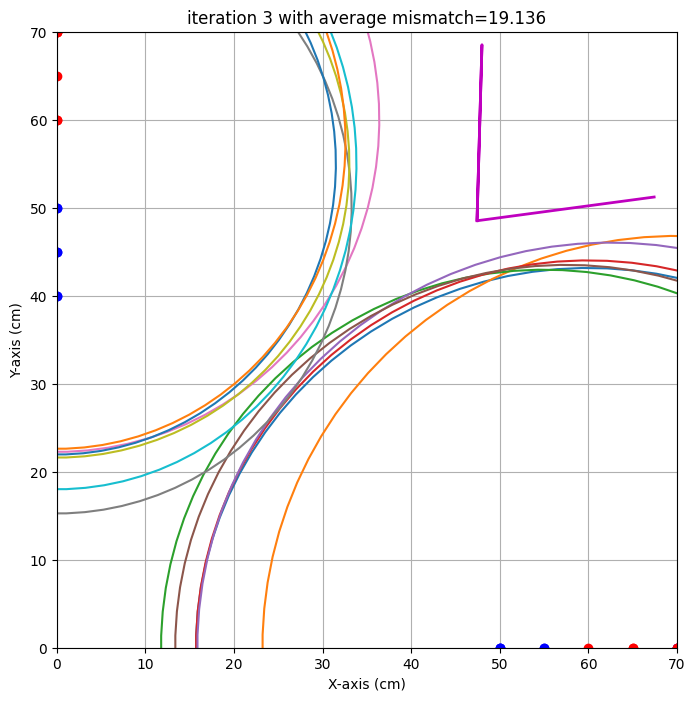

end iteration 3 with average mismatch=19.136


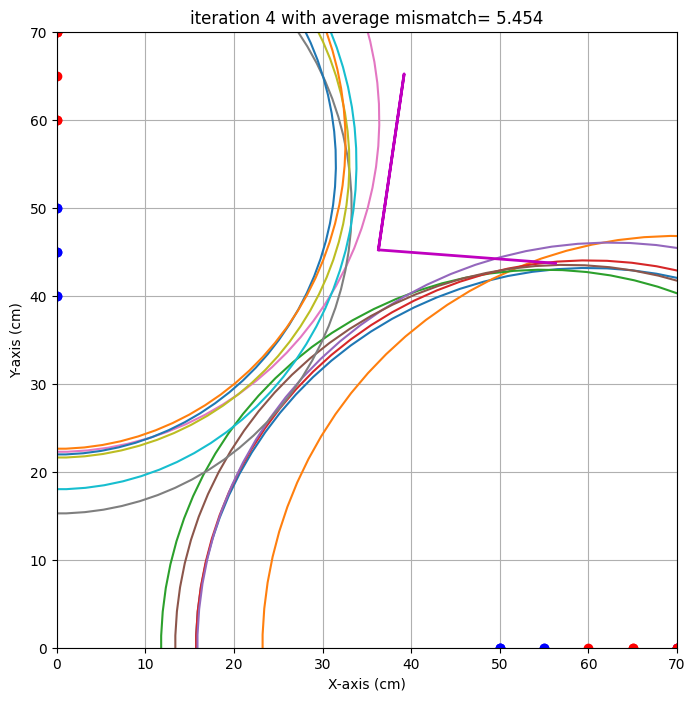

end iteration 4 with average mismatch= 5.454


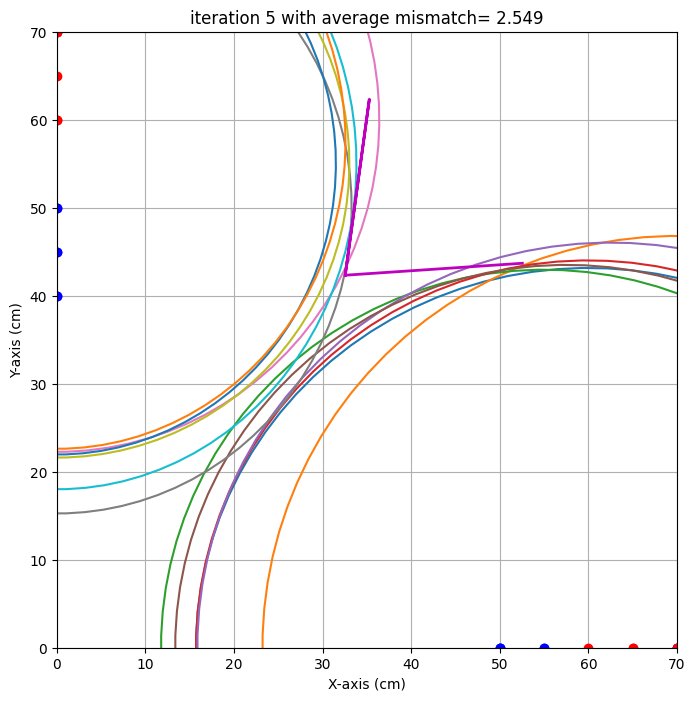

end iteration 5 with average mismatch= 2.549


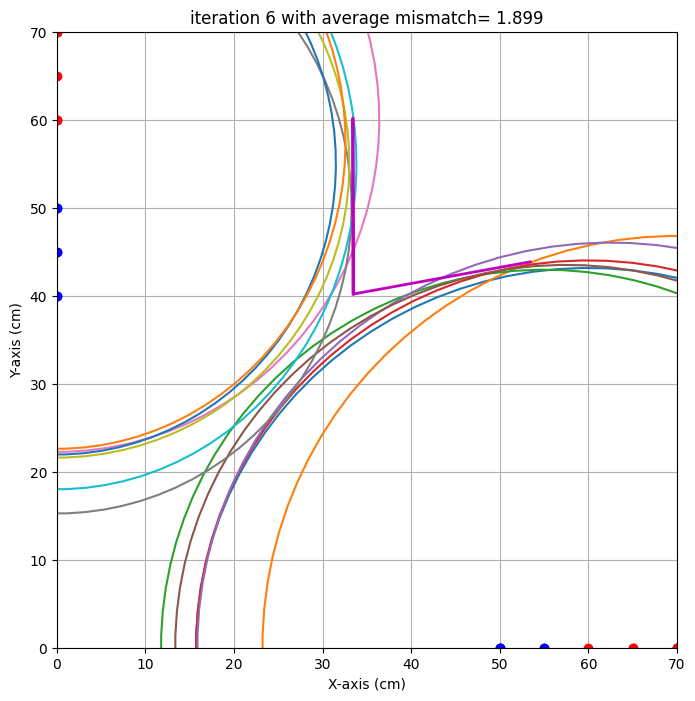

end iteration 6 with average mismatch= 1.899


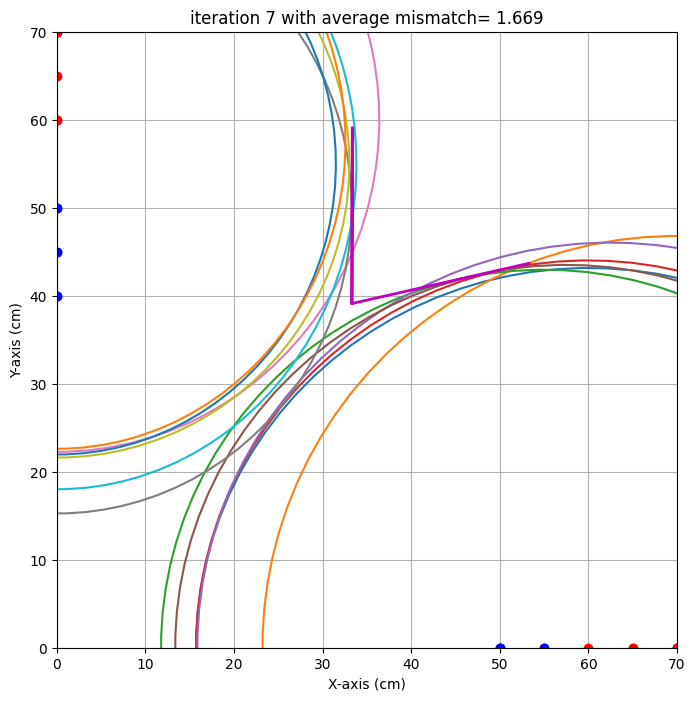

end iteration 7 with average mismatch= 1.669
end iteration 8 with average mismatch= 1.663
end iteration 9 with average mismatch= 1.643
end iteration 10 with average mismatch= 1.636
end iteration 11 with average mismatch= 1.601
end iteration 12 with average mismatch= 1.598
end iteration 13 with average mismatch= 1.597
end iteration 14 with average mismatch= 1.597
end iteration 15 with average mismatch= 1.597
end iteration 16 with average mismatch= 1.597
end iteration 17 with average mismatch= 1.597
end iteration 18 with average mismatch= 1.597
end iteration 19 with average mismatch= 1.597
end iteration 20 with average mismatch= 1.597
end iteration 21 with average mismatch= 1.597
end iteration 22 with average mismatch= 1.597
end iteration 23 with average mismatch= 1.597
end iteration 24 with average mismatch= 1.597
end iteration 25 with average mismatch= 1.597
end iteration 26 with average mismatch= 1.597
end iteration 27 with average mismatch= 1.593
end iteration 28 with average mismatc

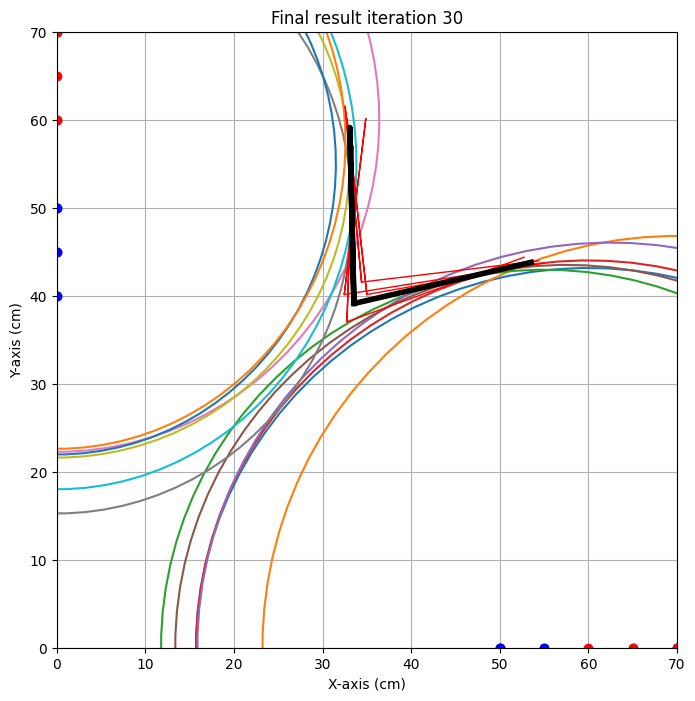

{'alpha': np.float64(13.170319762269736), 'alpha_eps': np.float64(6.973304185079039), 'beta': np.float64(-1.306988936295818), 'beta_eps': np.float64(8.26352822032346), 'x0': np.float64(33.53400577857399), 'x0_eps': np.float64(1.4651095489431754), 'y0': np.float64(39.11293068671975), 'y0_eps': np.float64(2.436275726106878)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


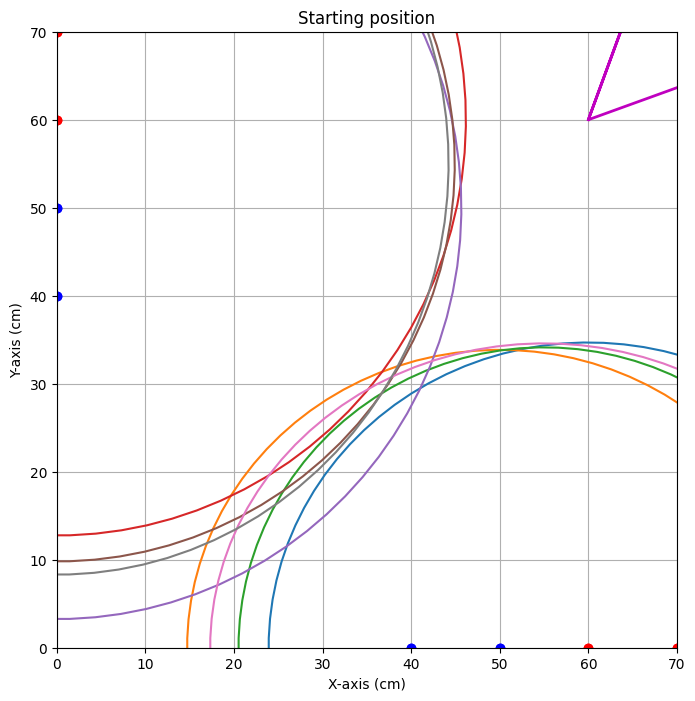


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


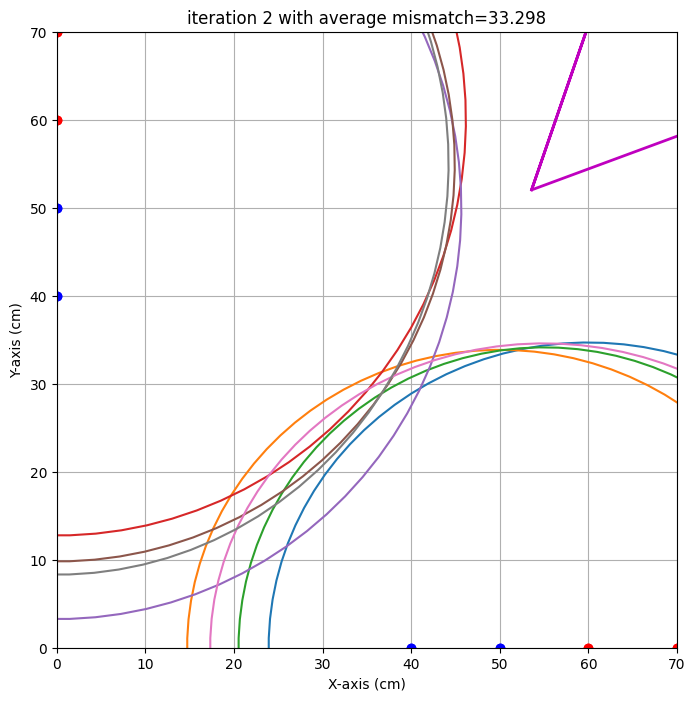

end iteration 2 with average mismatch=33.298


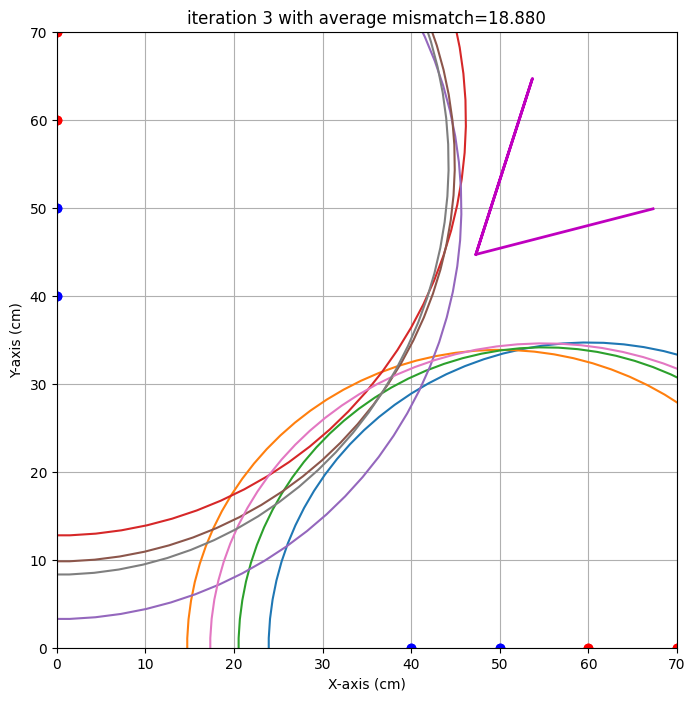

end iteration 3 with average mismatch=18.880


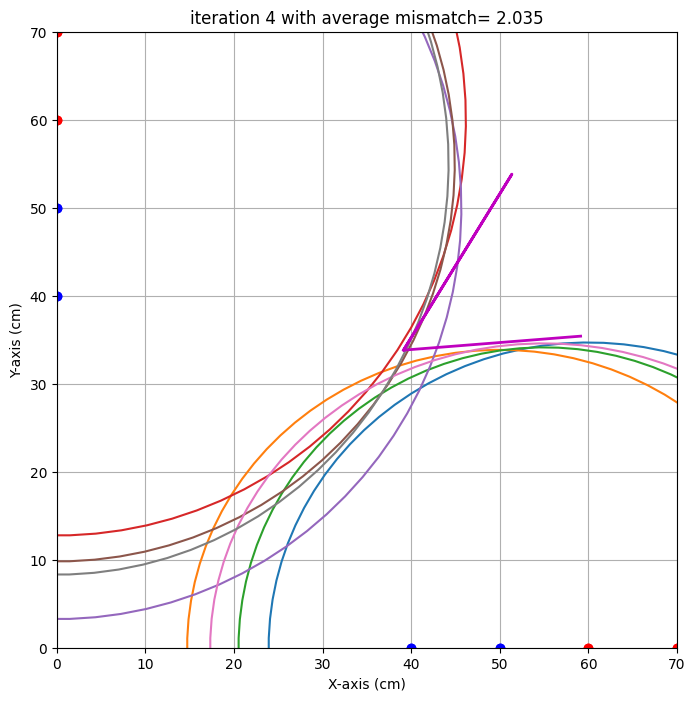

end iteration 4 with average mismatch= 2.035


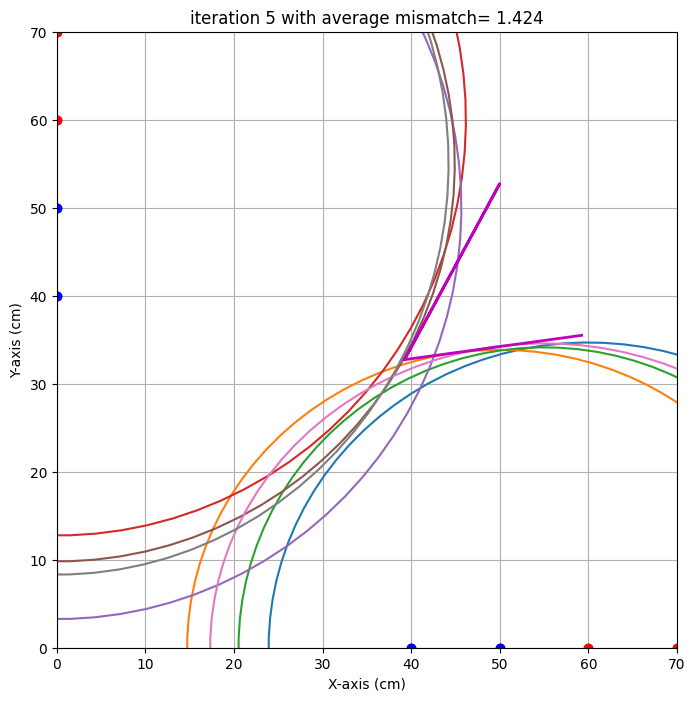

end iteration 5 with average mismatch= 1.424


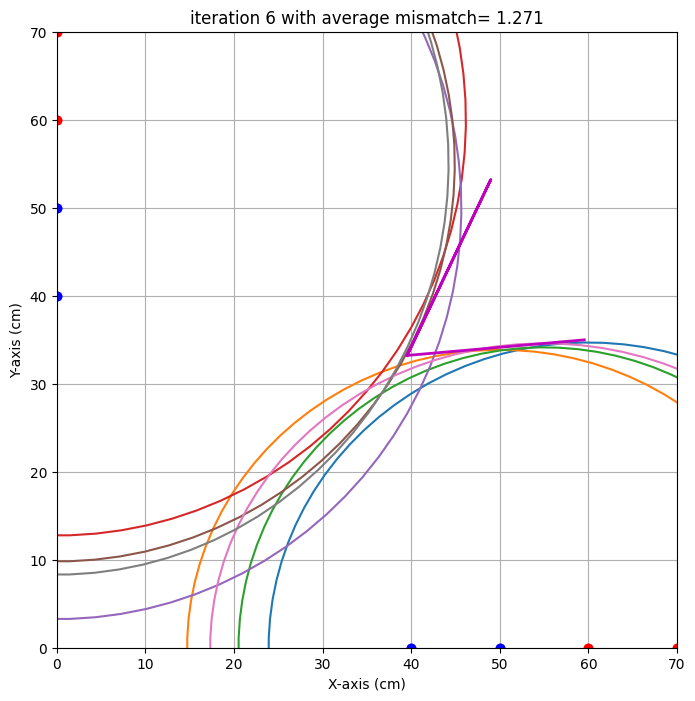

end iteration 6 with average mismatch= 1.271
end iteration 7 with average mismatch= 1.175


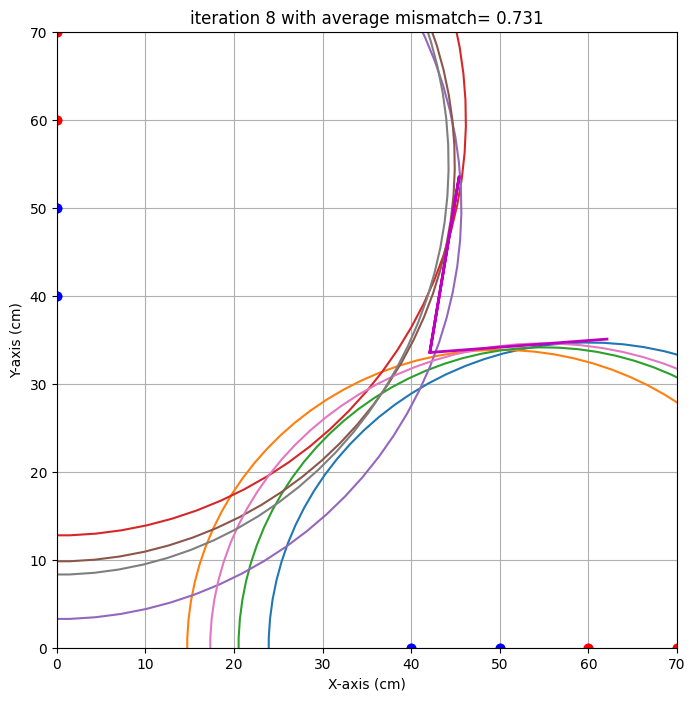

end iteration 8 with average mismatch= 0.731
end iteration 9 with average mismatch= 0.691
end iteration 10 with average mismatch= 0.676
end iteration 11 with average mismatch= 0.675
end iteration 12 with average mismatch= 0.675
end iteration 13 with average mismatch= 0.675
end iteration 14 with average mismatch= 0.675
end iteration 15 with average mismatch= 0.675
end iteration 16 with average mismatch= 0.675
end iteration 17 with average mismatch= 0.675
end iteration 18 with average mismatch= 0.675
end iteration 19 with average mismatch= 0.675
end iteration 20 with average mismatch= 0.675
end iteration 21 with average mismatch= 0.675
end iteration 22 with average mismatch= 0.675
end iteration 23 with average mismatch= 0.675
end iteration 24 with average mismatch= 0.675
end iteration 25 with average mismatch= 0.672
end iteration 26 with average mismatch= 0.666
end iteration 27 with average mismatch= 0.663
end iteration 28 with average mismatch= 0.663
end iteration 29 with average mismat

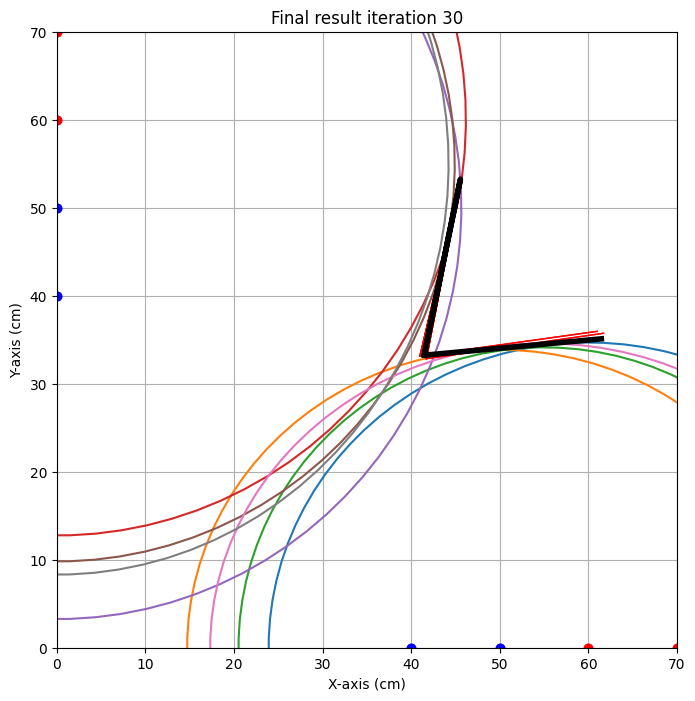

{'alpha': np.float64(5.322731346539063), 'alpha_eps': np.float64(2.9038879965082423), 'beta': np.float64(11.562124997823096), 'beta_eps': np.float64(1.56958651527437), 'x0': np.float64(41.46639817118284), 'x0_eps': np.float64(0.47526428848090063), 'y0': np.float64(33.23923998725048), 'y0_eps': np.float64(0.3962933531785424)}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 33.5 cm met een standaardafwijking van 1.5 cm 
y0 target is : 32.7. Gevonden waarde: 39.1 cm met een standaardafwijking van 2.4 cm 
alpha target is : 38.0. Gevonden waarde: 13.2 graden met een standaardafwijking van 7.0 graad 
beta target is : 7.0. Gevonden waarde: -1.3 graden met een standaardafwijking van 8.3 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.5 cm met een standaardafwijking van 0.5 cm 
y0 target is : 32.9. Gevonden waarde: 33.2 cm met een standaardafwijking van 0.4 cm 
alpha target is : 4.0. Gevonden waarde: 5.3 graden met een standaardafwijking van 2.9 graad 
beta target is : 23.0. Gevond

In [25]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 31,
                    'y0': 32.7,
                    'alpha' : 38,
                    'beta' : 7},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,88.6],
    #[60,0,40,0,200],
    [70,0,70,0,93.6],
    [60,0,50,0,86.5],
    [65,0,55,0,88.6],
    [70,0,55,0,93.3],  
    [65,0,50,0,88.3],
    [0,70,0,50,75.5],
    [0,60,0,40,69.5],
    [0,60,0,50,66.8],
    [0,70,0,40,74.0],
    [0,65,0,45,66.1],
    #[0,70,0,60,200],
    #[0,70,0,55,200],
    [0,70,0,45,69.8],

   
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  92.2
1   60   0  40   0  93.5
2   60   0  50   0  89.2
3   70   0  40   0  93.5
4   65   0  45   0  91.0
5   70   0  45   0  93.5
6    0  20   0  40  95.3
7    0  30   0  50  89.5
8    0  30   0  40  89.0
9    0  20   0  50  93.2
10   0  25   0  45  90.9


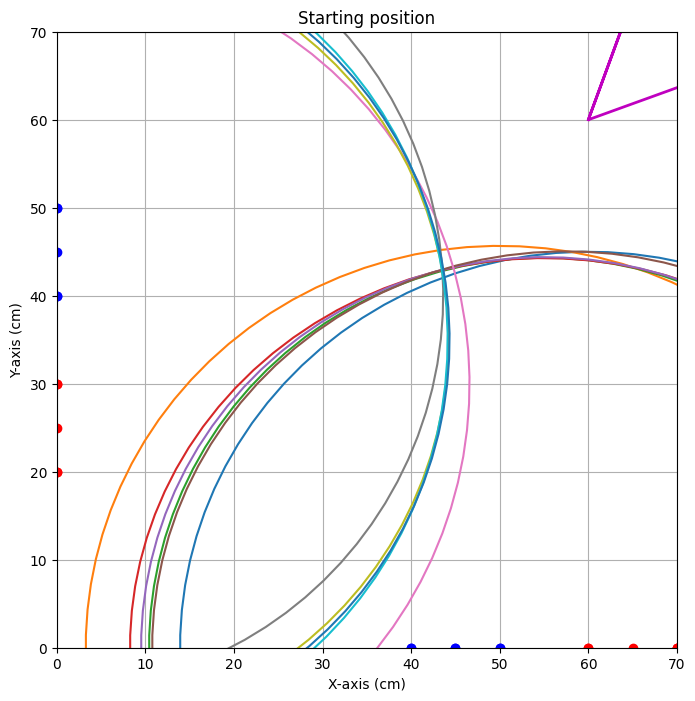


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=41.757


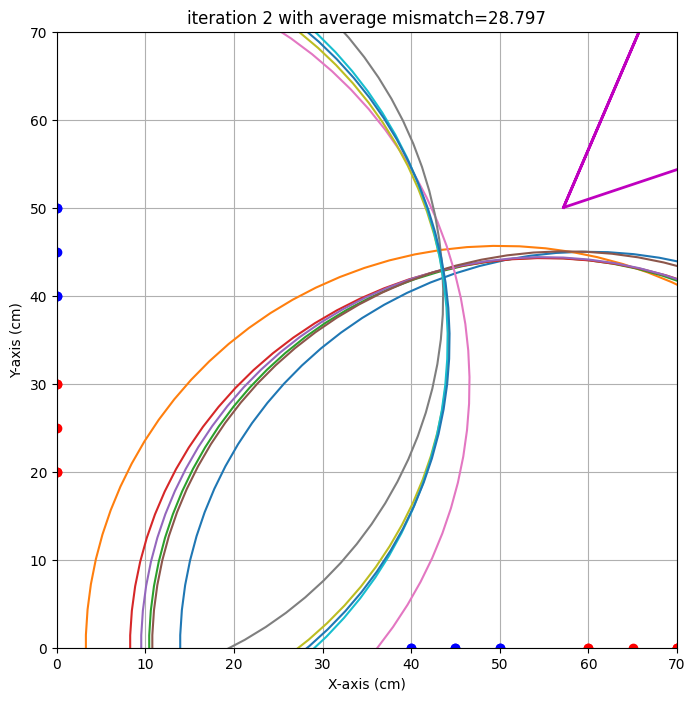

end iteration 2 with average mismatch=28.797


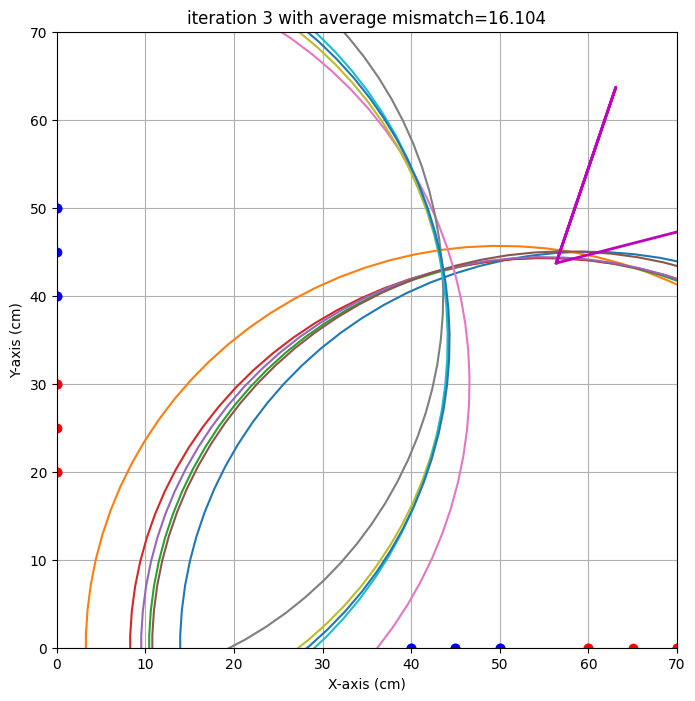

end iteration 3 with average mismatch=16.104


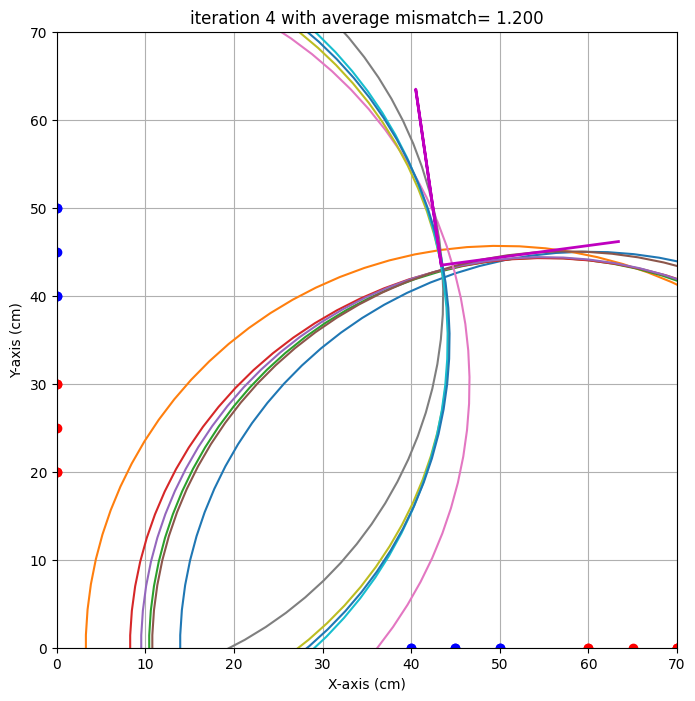

end iteration 4 with average mismatch= 1.200
end iteration 5 with average mismatch= 1.096
end iteration 6 with average mismatch= 1.086
end iteration 7 with average mismatch= 1.086
end iteration 8 with average mismatch= 1.020
end iteration 9 with average mismatch= 1.019
end iteration 10 with average mismatch= 1.019
end iteration 11 with average mismatch= 1.019
end iteration 12 with average mismatch= 1.019
end iteration 13 with average mismatch= 1.019
end iteration 14 with average mismatch= 1.019
end iteration 15 with average mismatch= 1.019
end iteration 16 with average mismatch= 1.019
end iteration 17 with average mismatch= 1.019
end iteration 18 with average mismatch= 1.012
end iteration 19 with average mismatch= 1.009
end iteration 20 with average mismatch= 0.962
end iteration 21 with average mismatch= 0.960
end iteration 22 with average mismatch= 0.959
end iteration 23 with average mismatch= 0.959
end iteration 24 with average mismatch= 0.959
end iteration 25 with average mismatch= 

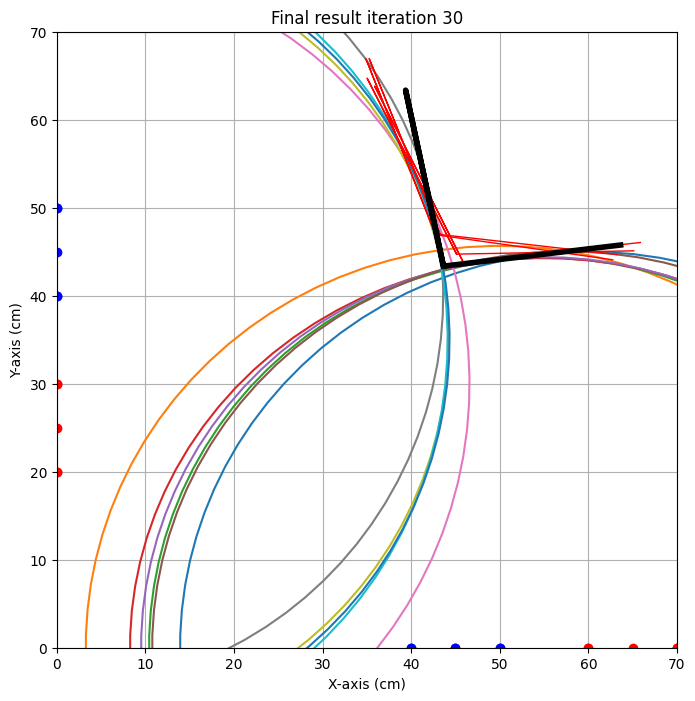

{'alpha': np.float64(6.8496274827172225), 'alpha_eps': np.float64(14.949390423991614), 'beta': np.float64(-12.070725599326101), 'beta_eps': np.float64(14.717207216403901), 'x0': np.float64(43.644127669263575), 'x0_eps': np.float64(2.2284748541931663), 'y0': np.float64(43.35882061682235), 'y0_eps': np.float64(3.597603974145244)}
test locatie 
x0 target is : 43.0. Gevonden waarde: 43.6 cm met een standaardafwijking van 2.2 cm 
y0 target is : 43.9. Gevonden waarde: 43.4 cm met een standaardafwijking van 3.6 cm 
alpha target is : 7.0. Gevonden waarde: 6.8 graden met een standaardafwijking van 14.9 graad 
beta target is : -17.0. Gevonden waarde: -12.1 graden met een standaardafwijking van 14.7 graad 



In [26]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 43 ,
                    'y0': 43.9 ,
                    'alpha' : 7 ,
                    'beta' : -17 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [70,0,50,0,92.2],
                    [60,0,40,0,93.5],
                    [60,0,50,0,89.2],
                    [70,0,40,0,93.5],
                    [65,0,45,0,91.0],
                    [70,0,45,0,93.5],
                    #[0,70,0,50,200],
                    [0,20,0,40,95.3],
                    [0,30,0,50,89.5],
                    [0,30,0,40,89.0],
                    [0,20,0,50,93.2],
                    [0,25,0,45,90.9],
                    #[0,35,0,25,95.5],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")